In [1]:
import os


os.environ['KAGGLE_API_TOKEN'] = "KGAT_ee0cb89df4a8c4eb288c28c19fcbdebf"


!kaggle competitions download -c house-prices-advanced-regression-techniques


!unzip -o house-prices-advanced-regression-techniques.zip

100%|████████████████████████████████████████| 199k/199k [00:00<00:00, 10.1MB/s]

Archive:  house-prices-advanced-regression-techniques.zip
  inflating: data_description.txt    
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


Dataprocessing

In [3]:
import pandas as pd

# 1. Load the extracted training dataset into the train_data DataFrame
train_data = pd.read_csv('train.csv')

# 2. Verify successful loading and inspect the dataset's basic structure
print("Dataset dimensions:", train_data.shape)
print("-" * 30)

# Examine feature data types and the count of non-null values
train_data.info()

Dataset dimensions: (1460, 81)
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   obj

In [4]:
posn_houses = train_data[train_data['Condition2'] == 'PosN']


cols_to_look = ['Id', 'SalePrice', 'Neighborhood', 'OverallQual', 'GrLivArea', 'Condition1', 'Condition2']
print(posn_houses[cols_to_look])

      Id  SalePrice Neighborhood  OverallQual  GrLivArea Condition1 Condition2
523  524     184750      Edwards           10       4676       PosN       PosN
825  826     385000      NridgHt           10       2084       PosN       PosN


Handling missing numerical values

In [6]:
# 1. Inspect the proportion of missing values across features
missing_ratio = train_data.isnull().sum() / len(train_data)
missing_features = missing_ratio[missing_ratio > 0].sort_values(ascending=False)

# Display the top 10 features with the highest missingness rates
print("Proportion of missing values by feature:\n", missing_features.head(10))
print("-" * 30)

Proportion of missing values by feature:
 PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageType      0.055479
GarageYrBlt     0.055479
GarageFinish    0.055479
dtype: float64
------------------------------


In [7]:
# Phase 1: Feature Engineering
# Transform informative missingness into binary indicators (1: Present, 0: Absent)
# ==========================================
train_data['HasPool'] = train_data['PoolQC'].notnull().astype(int)
train_data['HasAlley'] = train_data['Alley'].notnull().astype(int)
train_data['HasFence'] = train_data['Fence'].notnull().astype(int)
train_data['HasMisc'] = train_data['MiscFeature'].notnull().astype(int)

In [8]:
train_data_cleaned = train_data.drop(columns=['PoolQC', 'Alley', 'Fence', 'MiscFeature'])

In [9]:
# Generate a statistical summary for all numerical features
summary_stats = train_data_cleaned.describe()

# Display the descriptive statistics
summary_stats

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,HasPool,HasAlley,HasFence,HasMisc
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890,0.004795,0.062329,0.192466,0.036986
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883,0.069100,0.241835,0.394372,0.188793
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,0.000000,0.000000,0.000000,0.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000,0.000000,0.000000,0.000000,0.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000,0.000000,0.000000,0.000000,0.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000,0.000000,0.000000,0.000000,0.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
# Identify all remaining numerical features
numeric_cols = train_data_cleaned.select_dtypes(include=['int64', 'float64']).columns

# Calculate the skewness for all numerical features 
# (Skewness measures the asymmetry of the data distribution and the extent of its tail)
skewness = train_data_cleaned[numeric_cols].skew()

for col in numeric_cols:
    if train_data_cleaned[col].isnull().sum() > 0:

        # Obtain the absolute skewness of the feature
        col_skew = abs(skewness[col])

        # Imputation logic: If absolute skewness > 1.0 (highly skewed), use median; otherwise, use mean
        if col_skew > 1.0:
            fill_val = train_data_cleaned[col].median()
            method = "Median"
        else:
            fill_val = train_data_cleaned[col].mean()
            method = "Mean"

        # Execute the imputation
        train_data_cleaned[col] = train_data_cleaned[col].fillna(fill_val)
        print(f"Feature '{col}' (|Skewness|: {col_skew:.2f}) -> Imputed with {method}")

print("-" * 30)
print("Numerical feature imputation completed!")
print("Maximum missing values remaining in any feature:", train_data_cleaned.isnull().sum().max())

Feature 'LotFrontage' (|Skewness|: 2.16) -> Imputed with Median
Feature 'MasVnrArea' (|Skewness|: 2.67) -> Imputed with Median
Feature 'GarageYrBlt' (|Skewness|: 0.65) -> Imputed with Mean
------------------------------
Numerical feature imputation completed!
Maximum missing values remaining in any feature: 872


Handling Categorical Missingness

In [12]:
# Identify all categorical features
categorical_cols = train_data_cleaned.select_dtypes(include=['object']).columns

print("--- Diagnostic Check for Mode Imputation Risks ---")
for col in categorical_cols:
    missing_count = train_data_cleaned[col].isnull().sum()

    # Evaluate only features containing missing values
    if missing_count > 0:
        missing_ratio = missing_count / len(train_data_cleaned)

        # Calculate the relative frequency (proportions) of each category
        value_counts = train_data_cleaned[col].value_counts(normalize=True)
        top_1_ratio = value_counts.iloc[0] if len(value_counts) > 0 else 0
        top_2_ratio = value_counts.iloc[1] if len(value_counts) > 1 else 0

        print(f"\nFeature: {col}")
        print(f"Missingness Rate: {missing_ratio:.1%}")
        print(f"Mode (Top 1) Dominance: {top_1_ratio:.1%} | 2nd Most Frequent: {top_2_ratio:.1%}")

        # Generate automated imputation recommendations
        if missing_ratio > 0.1:
            print("[Recommendation] High missingness rate. Recommend imputing with 'None'.")
        elif (top_1_ratio - top_2_ratio) < 0.1:
            print("[Recommendation] Weak class dominance. High risk for mode imputation. Recommend imputing with 'None'.")
        else:
            print("[Recommendation] Strong class dominance and low missingness. Safe to proceed with mode imputation.")

--- Diagnostic Check for Mode Imputation Risks ---

Feature: MasVnrType
Missingness Rate: 59.7%
Mode (Top 1) Dominance: 75.7% | 2nd Most Frequent: 21.8%
[Recommendation] High missingness rate. Recommend imputing with 'None'.

Feature: BsmtQual
Missingness Rate: 2.5%
Mode (Top 1) Dominance: 45.6% | 2nd Most Frequent: 43.4%
[Recommendation] Weak class dominance. High risk for mode imputation. Recommend imputing with 'None'.

Feature: BsmtCond
Missingness Rate: 2.5%
Mode (Top 1) Dominance: 92.1% | 2nd Most Frequent: 4.6%
[Recommendation] Strong class dominance and low missingness. Safe to proceed with mode imputation.

Feature: BsmtExposure
Missingness Rate: 2.6%
Mode (Top 1) Dominance: 67.0% | 2nd Most Frequent: 15.5%
[Recommendation] Strong class dominance and low missingness. Safe to proceed with mode imputation.

Feature: BsmtFinType1
Missingness Rate: 2.5%
Mode (Top 1) Dominance: 30.2% | 2nd Most Frequent: 29.4%
[Recommendation] Weak class dominance. High risk for mode imputation. Re

1. Statistical Validation for 'None' Imputation
MasVnrType (59.7% missing) and FireplaceQu (47.3% missing): The exceptionally high missingness rates do not denote random errors; rather, they signify the physical absence of these amenities (i.e., the property possesses no masonry veneer or fireplace). Imputing 'None' strictly aligns with the structural reality of the dataset.

BsmtQual and BsmtFinType1: While exhibiting lower missing rates, these features lack a dominant mode (e.g., the top two categories compete at 45.6% vs. 43.4%). Forcing mode imputation in these instances would severely distort the underlying categorical distribution. Our diagnostic logic accurately identifies this risk and recommends 'None'.

2. Optimal Candidates for Mode Imputation: Electrical
Electrical (0.1% missing): This feature demonstrates both minimal missingness and extreme class dominance, with 91.4% of instances utilizing the standard electrical system (SBrkr). These sparse omissions are highly indicative of random human error during data entry (Missing Completely at Random - MCAR). Consequently, mode imputation serves as the most logically and statistically sound approach.

3. Diagnostic Caveats: Correlated Missingness in 'Garage' and 'Basement' Clusters
A critical empirical vulnerability arises when analyzing grouped structural features. Relying solely on localized, feature-by-feature diagnostics can lead to significant modeling errors.

The "Garage" Cluster: The missingness rates for GarageType, GarageFinish, GarageQual, and GarageCond converge precisely at 5.5%. This is not coincidental; it represents informative missingness, confirming that 5.5% of the properties physically lack a garage. Although an automated diagnostic might suggest mode imputation due to high localized class dominance (e.g., a 95% majority for a standard garage type), blindly executing this would artificially fabricate garages for these properties, introducing severe predictive distortion into the pricing model.

The "Basement" Cluster: Similarly, basement-related features consistently exhibit a uniform missingness rate between 2.5% and 2.6%, structurally signifying properties built without basements.

Conclusion for Clusters: For grouped structural features exhibiting correlated missingness, algorithmic mode suggestions must be overridden. These instances necessitate strict 'None' imputation to preserve the physical truth of the real estate data.

In [14]:
# 1. Execute mode imputation for statistically validated candidates
mode_cols = ['Electrical']
for col in mode_cols:
    # Extract the mode and apply imputation
    most_freq = train_data_cleaned[col].mode()[0]
    train_data_cleaned[col] = train_data_cleaned[col].fillna(most_freq)

# 2. Impute remaining categorical features with 'None' (indicating physical absence)
# Define features exhibiting informative missingness based on prior diagnostic analysis
none_cols = [
    'MasVnrType', 'FireplaceQu',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'
]

for col in none_cols:
    train_data_cleaned[col] = train_data_cleaned[col].fillna("None")

# 3. Final validation
print("Categorical feature imputation completed.")
print("Maximum missing values remaining in any feature:", train_data_cleaned.isnull().sum().max())

Categorical feature imputation completed.
Maximum missing values remaining in any feature: 0


In [15]:
print("Cleaned dataset dimensions:", train_data_cleaned.shape)

Cleaned dataset dimensions: (1460, 81)


In [16]:
# Automatically convert all categorical features into a One-Hot Encoded format
# Apply drop_first=True to mitigate perfect multicollinearity (the dummy variable trap) 
# by representing N categories with N-1 binary indicators.
train_data_final = pd.get_dummies(train_data_cleaned, drop_first=True)

print("Original dataset dimensions:", train_data_cleaned.shape)
print("Dimensions after One-Hot Encoding:", train_data_final.shape)

# Display the first five records of the finalized dataset
train_data_final.head()

Original dataset dimensions: (1460, 81)
Dimensions after One-Hot Encoding: (1460, 252)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


Baseline Models

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

Comparative distribution analysis of SalePrice to evaluate the normalization efficacy of log transformation

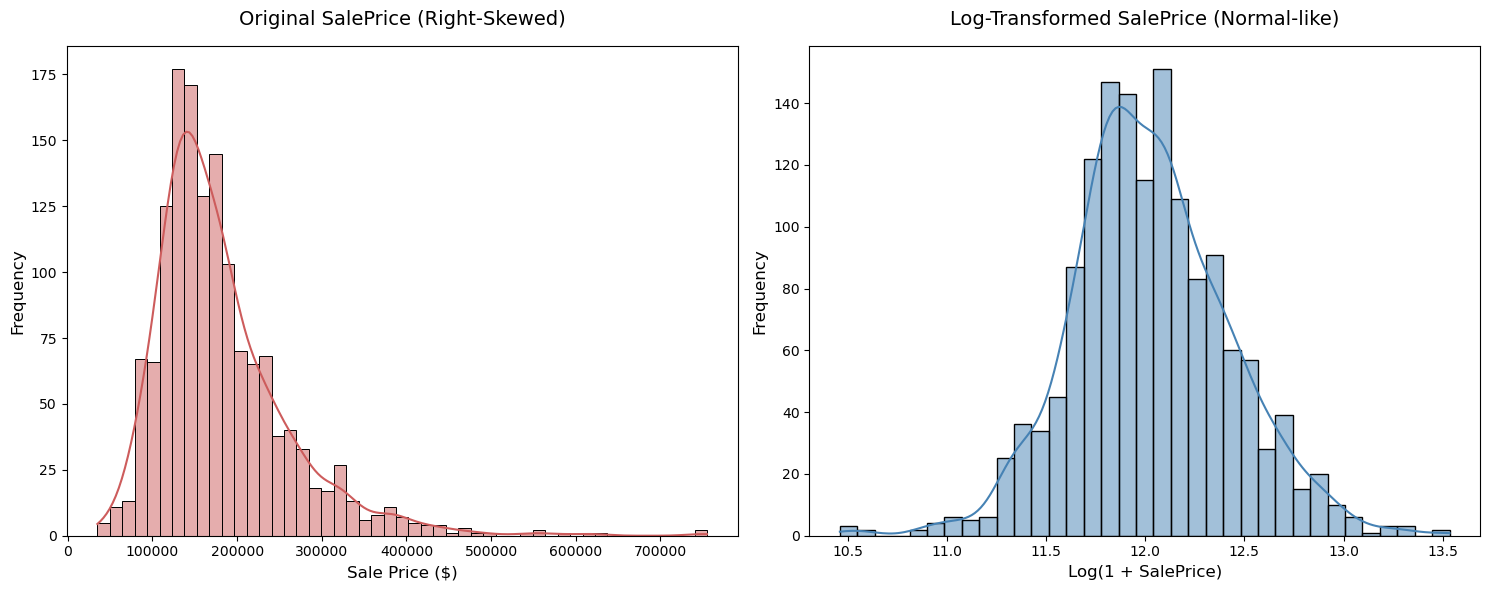

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up the figure dimensions (1x2 side-by-side subplots)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left Subplot: Original SalePrice (Demonstrating Right-Skewness) ---
sns.histplot(train_data['SalePrice'], kde=True, ax=axes[0], color='indianred')
axes[0].set_title('Original SalePrice (Right-Skewed)', fontsize=14, pad=15)
axes[0].set_xlabel('Sale Price ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# --- Right Subplot: Log-Transformed SalePrice (Approximating Normal Distribution) ---
# Utilizing np.log1p (log(1+x)) to handle potential zero values and stabilize variance
sns.histplot(np.log1p(train_data['SalePrice']), kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Log-Transformed SalePrice (Normal-like)', fontsize=14, pad=15)
axes[1].set_xlabel('Log(1 + SalePrice)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

Due to the pronounced right-skewed distribution of the original SalePrice data, we applied a log transformation: $y = \log(1 + \text{SalePrice})$. This transformation not only aligns the residual distribution with the normality assumptions required for linear regression but also effectively converts absolute errors into relative (proportional) errors. Consequently, this ensures that prediction errors are comparable across both high-value and low-value properties, achieving scale-invariance in our model evaluation.

Data Splitting / Feature-Target Isolation

In [23]:
# 1. Isolate the target variable (y) using log transformation
y = np.log1p(train_data_final["SalePrice"])

# 2. Construct the feature matrix (X) by dropping the target ('SalePrice') and identifier ('Id')
X = train_data_final.drop(columns=["SalePrice", "Id"], errors="ignore")

print("Feature matrix (X) dimensions:", X.shape)
print("Target variable (y) dimensions:", y.shape)

Feature matrix (X) dimensions: (1460, 250)
Target variable (y) dimensions: (1460,)


Data Partition

In [25]:
from sklearn.model_selection import train_test_split

# Partition the dataset into an 80% Development set (Dev) and a 20% Final Hold-out Test set.
X_dev, X_final_test, y_dev, y_final_test = train_test_split(X, y, test_size=0.2, random_state=42)

Feature Transformation (yeo-johnson' method)

In [27]:
from sklearn.preprocessing import PowerTransformer
import pandas as pd

# 1. Instantiate the PowerTransformer (as a robust alternative to StandardScaler)
# The 'yeo-johnson' method automatically stabilizes variance and minimizes skewness across features.
# standardize=True ensures the data is mapped to a zero-mean, unit-variance distribution post-transformation.
scaler = PowerTransformer(method='yeo-johnson', standardize=True)

# ==========================================
# Step 1: Apply fit_transform to the Development set (X_dev)
# The scaler learns the distribution parameters (the "scale") from the 80% data subset
# and subsequently maps it to a normalized feature space.
# ==========================================
X_dev_scaled = pd.DataFrame(
    scaler.fit_transform(X_dev), 
    columns=X_dev.columns, 
    index=X_dev.index
)

# ==========================================
# Step 2: Apply transform (only) to the Final Hold-out Test set
# ==========================================
X_final_test_scaled = pd.DataFrame(
    scaler.transform(X_final_test), 
    columns=X_final_test.columns, 
    index=X_final_test.index
)

print("Standardization and Power Transformation completed.")
print(f"Dimensions of X_dev_scaled: {X_dev_scaled.shape}")
print(f"Dimensions of X_final_test_scaled: {X_final_test_scaled.shape}")

Standardization and Power Transformation completed.
Dimensions of X_dev_scaled: (1168, 250)
Dimensions of X_final_test_scaled: (292, 250)


進行一般標準化後，結果並沒有比原始資料的結果好
一般標準化後的結果(CV RMSE):

1. 一般線性迴歸 (Baseline): 0.1636
2. Lasso 迴歸模型 RMSE: 0.1480
3. Ridge 迴歸模型 RMSE: 0.1437

未標準化的結果(CV RMSE)：

1. 一般線性迴歸 (Baseline): 0.1657
2. Lasso 迴歸模型 RMSE: 0.1445
3. Ridge 迴歸模型 RMSE: 0.1426

利用 'yeo-johnson' 將偏態修掉可以使線性模型表現更好，然而修改偏態後務必要標準化，不然不同 features 會存在非常大的數值差異，對 baseline 會造成嚴重的影響，但對於 regularized 的影響會較小，因為 $\alpha$ 值可以將過大或者過小的值壓回正常的數值區間

In [29]:
from sklearn.metrics import mean_squared_error
def rmse_log(y_true, y_pred):
  return np.sqrt(mean_squared_error(y_true, y_pred))

Establishing a Predictive Baseline: Linear Regression with 5-Fold Cross-Validation

In [31]:
# 1. Initialize the Baseline Model (Linear Regression)
linear_model = LinearRegression()

# 2. Configure the K-Fold Cross-Validation strategy (K=5)
# 'shuffle=True' ensures unbiased partitions by randomizing the data before splitting
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. Perform 5-Fold Cross-Validation
# We use 'neg_mean_squared_error' as scikit-learn's convention treats higher scores as better; 
# thus, metrics meant to be minimized (like MSE) are represented as negative values.
scores = cross_val_score(linear_model, X_dev_scaled, y_dev, cv=kf, scoring='neg_mean_squared_error')

# 4. Convert scores to Root Mean Squared Error (RMSE)
# Reversing the negation (abs) and applying the square root (np.sqrt) for intuitive evaluation
rmse_scores = np.sqrt(np.abs(scores))

# 5. Performance Evaluation Report
print("--- 5-Fold Cross-Validation (Linear Regression) ---")
for i, score in enumerate(rmse_scores):
    print(f"Fold {i+1} RMSE: {score:.4f}")

baseline_rmse_scores = rmse_scores.mean()

print("-" * 30)
print(f"Baseline Mean RMSE: {rmse_scores.mean():.4f}")

--- 5-Fold Cross-Validation (Linear Regression) ---
Fold 1 RMSE: 0.1429
Fold 2 RMSE: 0.1429
Fold 3 RMSE: 0.1793
Fold 4 RMSE: 0.1359
Fold 5 RMSE: 0.1494
------------------------------
Baseline Mean RMSE: 0.1501


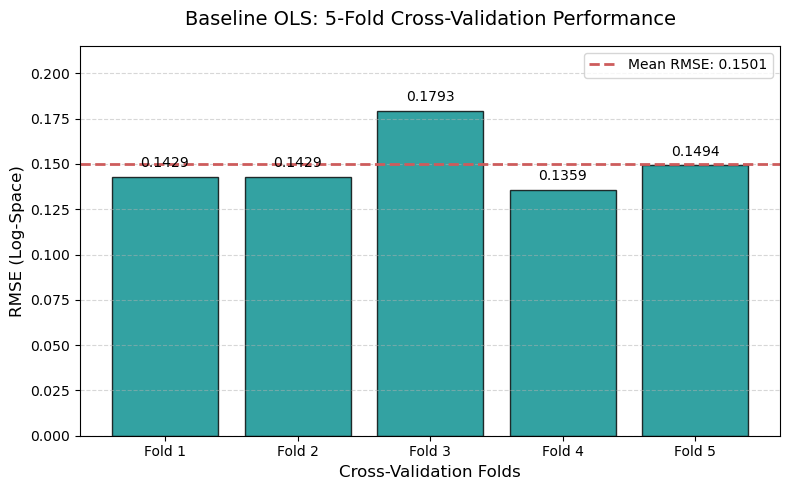

In [32]:
# Core Purpose: Visualize the performance stability of the baseline model 
# across different folds to assess variance and overall predictive consistency.

folds = [f"Fold {i+1}" for i in range(len(rmse_scores))]
mean_rmse = baseline_rmse_scores

plt.figure(figsize=(8, 5))

# Plot the individual RMSE for each cross-validation fold as a bar chart
bars = plt.bar(folds, rmse_scores, color='darkcyan', alpha=0.8, edgecolor='black')

# Draw a red dashed horizontal line representing the Mean RMSE for benchmarking
plt.axhline(y=mean_rmse, color='indianred', linestyle='--', linewidth=2, label=f'Mean RMSE: {mean_rmse:.4f}')

# Configure plot titles and axis labels with academic formatting
plt.title('Baseline OLS: 5-Fold Cross-Validation Performance', fontsize=14, pad=15)
plt.xlabel('Cross-Validation Folds', fontsize=12)
plt.ylabel('RMSE (Log-Space)', fontsize=12)

# Annotate each bar with its specific RMSE value for precise numerical inspection
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(rmse_scores)*0.02), 
             f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

# Fine-tune visual aesthetics and layout
plt.ylim(0, max(rmse_scores) * 1.2) # Reserve space at the top for numerical annotations
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Final Generalization Evaluation: Baseline Model Performance on the Hold-out Test Set

In [34]:
# 1. Instantiate a fresh model instance for final evaluation
baseline_model = LinearRegression()

# 2. Train on the entire Development set (utilizing the full 80% data pool)
# After validating via K-Fold, we use the entire dev set to maximize the learning signal.
baseline_model.fit(X_dev_scaled, y_dev)

# 3. Predict on the "unseen" Final Test set (Hold-out set)
# This represents the model's first encounter with these records, 
# providing an unbiased measure of its true generalization capability.
baseline_preds = baseline_model.predict(X_final_test_scaled)

# 4. Calculate the Final Test RMSE (Log-Space)
# Utilizing the previously defined rmse_log function for performance metrics
baseline_test_rmse = rmse_log(y_final_test, baseline_preds)

print("--- Final Generalization Performance (Baseline Test Error) ---")
print(f"Baseline Test RMSE (Log-Space): {baseline_test_rmse:.4f}")

# Calculate the estimated mean percentage error to assess monetary impact
print(f"Baseline Mean Percentage Error (Approx. USD impact): {(np.exp(baseline_test_rmse) - 1)*100:.2f}%")

--- Final Generalization Performance (Baseline Test Error) ---
Baseline Test RMSE (Log-Space): 0.2445
Baseline Mean Percentage Error (Approx. USD impact): 27.69%


Diagnostic Visualization: Actual vs. Predicted Analysis for Baseline OLS

<>:18: SyntaxWarning: invalid escape sequence '\h'
<>:18: SyntaxWarning: invalid escape sequence '\h'
/var/folders/l_/nv0813dj7fb6xj2x4dql_5ww0000gn/T/ipykernel_18687/3034922924.py:18: SyntaxWarning: invalid escape sequence '\h'
  label='Perfect Prediction ($y = \hat{y}$)')


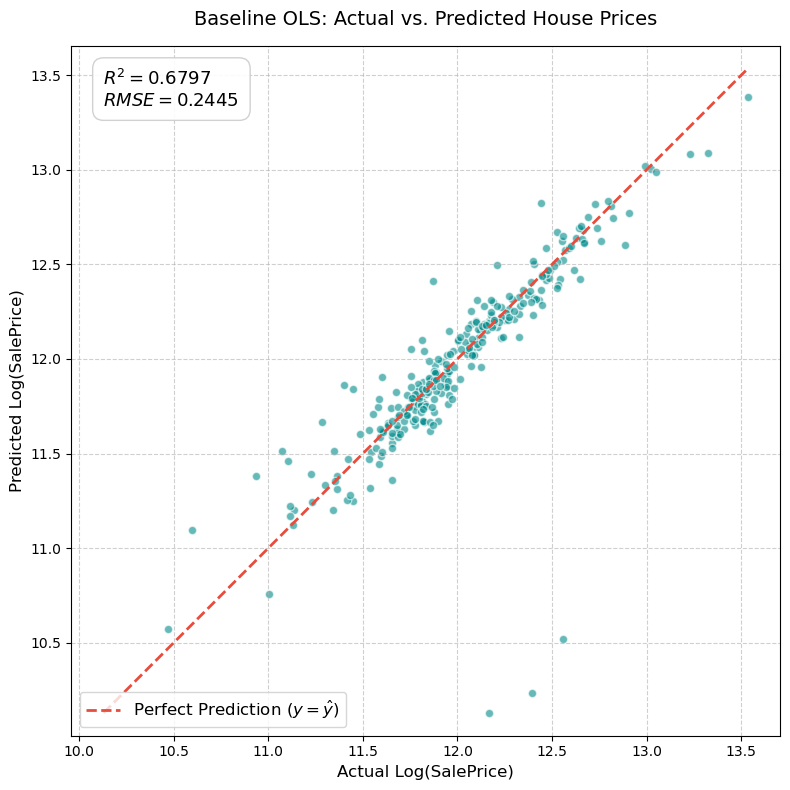

In [36]:
from sklearn.metrics import r2_score

# 1. Compute evaluation metrics on the Final Test set
baseline_r2 = r2_score(y_final_test, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_final_test, baseline_preds))

plt.figure(figsize=(8, 8))

# 2. Plot prediction scatter points 
plt.scatter(y_final_test, baseline_preds, alpha=0.6, color='darkcyan', edgecolor='white')

# 3. Construct the 45-degree Identity Line (Perfect Prediction Line)
# This serves as the benchmark where Predicted equals Actual
min_val = min(np.min(y_final_test), np.min(baseline_preds))
max_val = max(np.max(y_final_test), np.max(baseline_preds))
plt.plot([min_val, max_val], [min_val, max_val], 
         color='#E74C3C', linestyle='--', linewidth=2, 
         label='Perfect Prediction ($y = \hat{y}$)')

plt.title('Baseline OLS: Actual vs. Predicted House Prices', fontsize=14, pad=15)
plt.xlabel('Actual Log(SalePrice)', fontsize=12)
plt.ylabel('Predicted Log(SalePrice)', fontsize=12)

plt.text(min_val, max_val, f'$R^2 = {baseline_r2:.4f}$\n$RMSE = {baseline_rmse:.4f}$',
         fontsize=13, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#ccc'))


plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=12)

plt.axis('equal') 
plt.tight_layout()

plt.show()

Feature Importance Analysis: Identifying Top Predictors in Baseline OLS

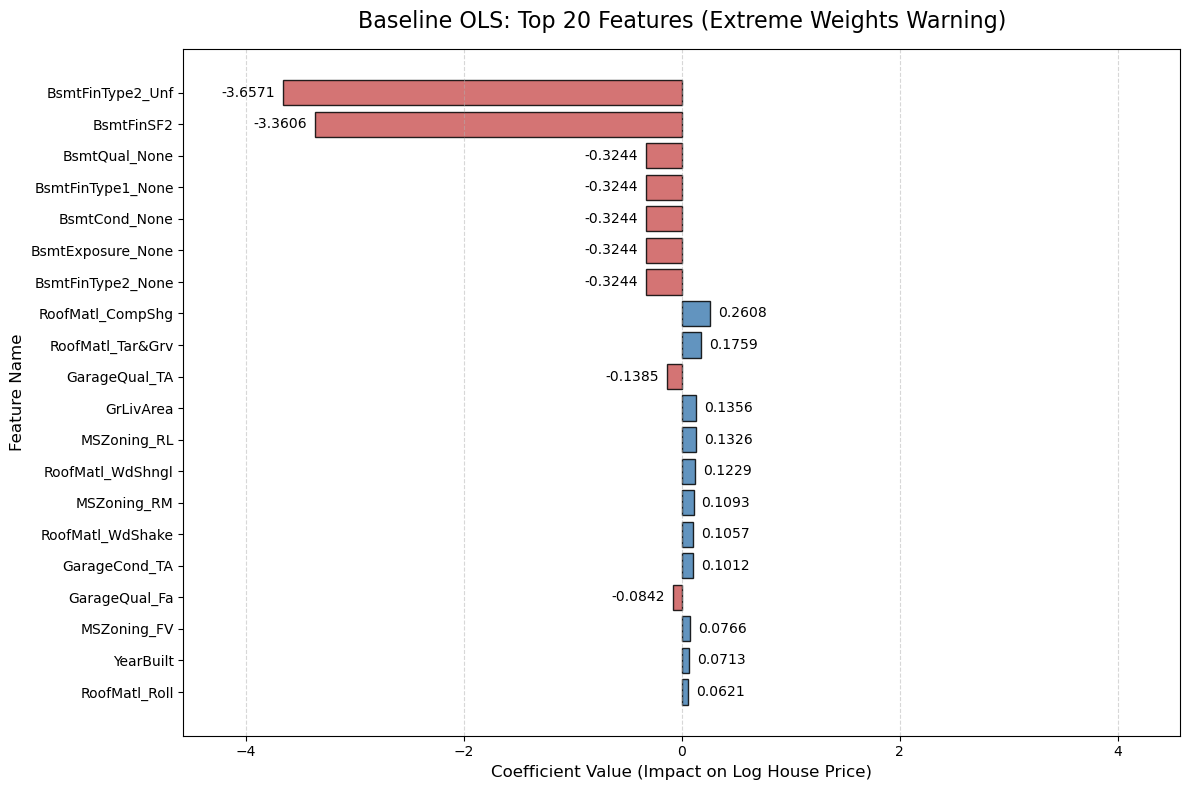

In [38]:
# 1. Extract coefficients and corresponding feature names
ols_coefs = baseline_model.coef_  
feature_names = X_dev_scaled.columns 

# 2. Construct a DataFrame and compute absolute values 
# Absolute values allow us to rank predictors by total influence, regardless of direction.
ols_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ols_coefs,
    'Abs_Coefficient': np.abs(ols_coefs)
})

# 3. Isolate the top 20 features by magnitude
top_20_ols = ols_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

# CRITICAL ADJUSTMENT: Reverse the order 
# This ensures the most influential features are plotted at the top of the horizontal bar chart.
top_20_ols = top_20_ols.iloc[::-1]

# 4. Visualize coefficients with a dual-color horizontal bar chart
plt.figure(figsize=(12, 8))

# Color coding: steelblue for positive correlation, indianred for negative correlation.
# Consistency with prior Ridge/Lasso visualizations is maintained.
colors = ['indianred' if c < 0 else 'steelblue' for c in top_20_ols['Coefficient']]

bars = plt.barh(top_20_ols['Feature'], top_20_ols['Coefficient'], 
                color=colors, edgecolor='black', alpha=0.85)

plt.title('Baseline OLS: Top 20 Features (Extreme Weights Warning)', fontsize=16, pad=15)
plt.xlabel('Coefficient Value (Impact on Log House Price)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 5. Add numerical annotations 
# Logic dynamically determines label placement (left vs. right) based on the coefficient's sign.
max_abs_val = top_20_ols['Abs_Coefficient'].max()
offset = max_abs_val * 0.02 # Buffer for text placement

for index, bar in enumerate(bars):
    val = bar.get_width()
    if val < 0:
        plt.text(val - offset, index, f'{val:.4f}', va='center', ha='right', fontsize=10)
    else:
        plt.text(val + offset, index, f'{val:.4f}', va='center', ha='left', fontsize=10)

# 6. Dynamically extend the X-axis to prevent label clipping
plt.xlim(-max_abs_val * 1.25, max_abs_val * 1.25)

plt.tight_layout()
plt.show()

Find Lasso and Ridge models alpha

In [40]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import RidgeCV, LassoCV, Ridge, Lasso
import numpy as np

# 1. Automated Hyperparameter Tuning and Training
# Lasso typically benefits from smaller alpha values to facilitate sparse feature selection.
lasso_alphas = np.logspace(-5, -1, 50)

# Ridge search space is centered around moderate values (previous diagnostics indicated ~5.96).
ridge_alphas = np.logspace(-1, 3, 50)

# Utilize CV-integrated estimators to find the optimal alpha using the predefined K-Fold (kf).
lasso_cv = LassoCV(alphas=lasso_alphas, cv=kf, max_iter=10000)
ridge_cv = RidgeCV(alphas=ridge_alphas, cv=kf)

print("Searching for optimal alpha values in logarithmic space...")
lasso_cv.fit(X_dev_scaled, y_dev)
ridge_cv.fit(X_dev_scaled, y_dev)

# 2. Model Instantiation with Optimal Hyperparameters
# Alpha represents 'regularization strength'; higher values impose a stricter penalty on feature weights.
lasso_model = Lasso(alpha=lasso_cv.alpha_)
ridge_model = Ridge(alpha=ridge_cv.alpha_)

# 3. Performance Evaluation via 5-Fold Cross-Validation
lasso_scores = cross_val_score(lasso_model, X_dev_scaled, y_dev, cv=kf, scoring='neg_mean_squared_error')
ridge_scores = cross_val_score(ridge_model, X_dev_scaled, y_dev, cv=kf, scoring='neg_mean_squared_error')

# 4. Compute RMSE Arrays
# Extracting the 5 individual fold scores for distribution analysis.
lasso_rmse_scores = np.sqrt(np.abs(lasso_scores))
ridge_rmse_scores = np.sqrt(np.abs(ridge_scores))

# 5. Calculate Aggregate Performance Metrics
lasso_mean_rmse = lasso_rmse_scores.mean()
ridge_mean_rmse = ridge_rmse_scores.mean()

print("\nModel Evaluation Summary")
print("-" * 40)
print(f"Lasso Optimal Alpha: {lasso_cv.alpha_:.4f}")
print(f"Ridge Optimal Alpha: {ridge_cv.alpha_:.4f}")
print("-" * 30)
print(f"1. Ordinary Least Squares (Baseline): {baseline_rmse_scores:.4f}")
print(f"2. Lasso Regression RMSE:           {lasso_mean_rmse:.4f}")
print(f"3. Ridge Regression RMSE:           {ridge_mean_rmse:.4f}")

Searching for optimal alpha values in logarithmic space...

Model Evaluation Summary
----------------------------------------
Lasso Optimal Alpha: 0.0041
Ridge Optimal Alpha: 268.2696
------------------------------
1. Ordinary Least Squares (Baseline): 0.1501
2. Lasso Regression RMSE:           0.1323
3. Ridge Regression RMSE:           0.1346


Model Stability Diagnostics: Lasso Regression 5-Fold Performance Visualization

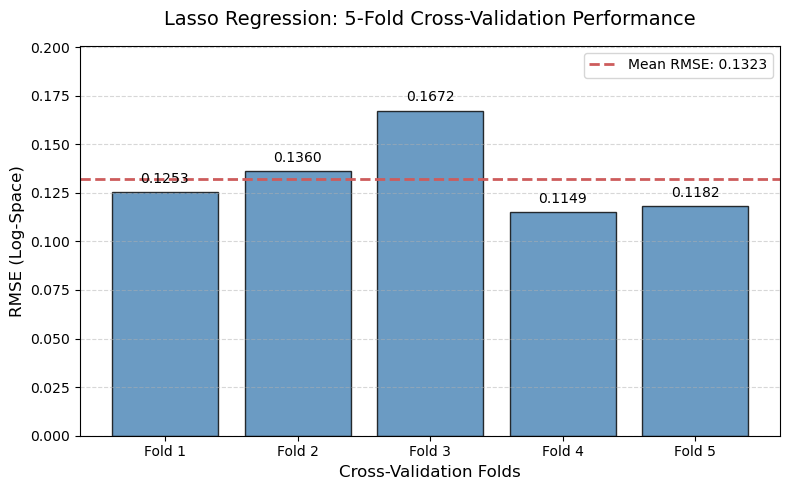

In [42]:
# Ensure lasso_rmse_scores and lasso_mean_rmse have been computed in the previous session
folds = [f"Fold {i+1}" for i in range(len(lasso_rmse_scores))]

plt.figure(figsize=(8, 5))

# 1. Plot individual fold RMSE as a bar chart
bars = plt.bar(folds, lasso_rmse_scores, color='steelblue', alpha=0.8, edgecolor='black')

# 2. Overlay a red dashed line representing the Mean RMSE for benchmarking
plt.axhline(y=lasso_mean_rmse, color='indianred', linestyle='--', linewidth=2, label=f'Mean RMSE: {lasso_mean_rmse:.4f}')

# 3. Configure titles and axis labels for the Lasso model
plt.title('Lasso Regression: 5-Fold Cross-Validation Performance', fontsize=14, pad=15)
plt.xlabel('Cross-Validation Folds', fontsize=12)
plt.ylabel('RMSE (Log-Space)', fontsize=12)

# 4. Annotate each bar with its precise RMSE value for granular inspection
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(lasso_rmse_scores)*0.02), 
             f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

# 5. Refine plot aesthetics and layout
plt.ylim(0, max(lasso_rmse_scores) * 1.2) # Reserve headspace for numerical labels
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Model Stability Diagnostics: Ridge Regression 5-Fold Performance Visualization

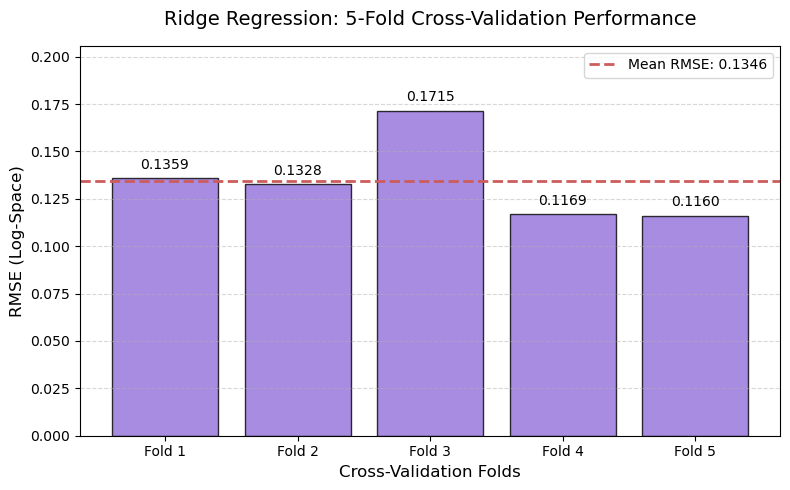

In [44]:
# Ensure ridge_rmse_scores (5-element array) and ridge_mean_rmse have been pre-computed
folds = [f"Fold {i+1}" for i in range(len(ridge_rmse_scores))]

plt.figure(figsize=(8, 5))

# 1. Plot the RMSE for each individual fold as a bar chart
bars = plt.bar(folds, ridge_rmse_scores, color='mediumpurple', alpha=0.8, edgecolor='black')

# 2. Overlay a red dashed horizontal line representing the Mean RMSE for benchmarking
plt.axhline(y=ridge_mean_rmse, color='indianred', linestyle='--', linewidth=2, label=f'Mean RMSE: {ridge_mean_rmse:.4f}')

# 3. Configure the title and axis labels for Ridge Regression performance
plt.title('Ridge Regression: 5-Fold Cross-Validation Performance', fontsize=14, pad=15)
plt.xlabel('Cross-Validation Folds', fontsize=12)
plt.ylabel('RMSE (Log-Space)', fontsize=12)

# 4. Annotate each bar with its specific RMSE value for precise numerical comparison
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(ridge_rmse_scores)*0.02), 
             f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

# 5. Fine-tune visual aesthetics and scaling
plt.ylim(0, max(ridge_rmse_scores) * 1.2) # Reserve space at the top for annotations
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

Hyperparameter Sensitivity Analysis: Visualizing the Lasso Regression Alpha Path

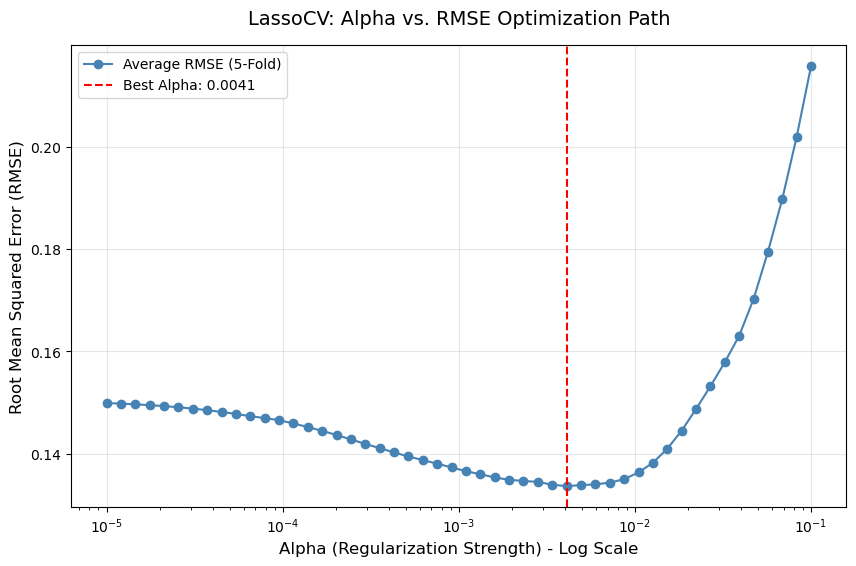

In [46]:
# We average across the folds (axis=1) to obtain the mean MSE for each alpha candidate
mse_mean = lasso_cv.mse_path_.mean(axis=1)

# Convert Mean Squared Error (MSE) to RMSE for intuitive evaluation
rmse_mean = np.sqrt(mse_mean)

plt.figure(figsize=(10, 6))

# Plot the relationship between Alpha and Average RMSE
plt.plot(lasso_cv.alphas_, rmse_mean, marker='o', linestyle='-', color='steelblue', label='Average RMSE (5-Fold)')

# Indicate the selected "Best Alpha" with a vertical dashed line
plt.axvline(lasso_cv.alpha_, color='r', linestyle='--', label=f'Best Alpha: {lasso_cv.alpha_:.4f}')

# Set X-axis to logarithmic scale to match the logspace distribution of alpha values
plt.xscale('log')

plt.title('LassoCV: Alpha vs. RMSE Optimization Path', fontsize=14, pad=15)
plt.xlabel('Alpha (Regularization Strength) - Log Scale', fontsize=12)
plt.ylabel('Root Mean Squared Error (RMSE)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Hyperparameter Sensitivity Analysis: Visualizing the Ridge Regression Alpha Path

Computing Ridge RMSE across varying Alpha values, please wait...


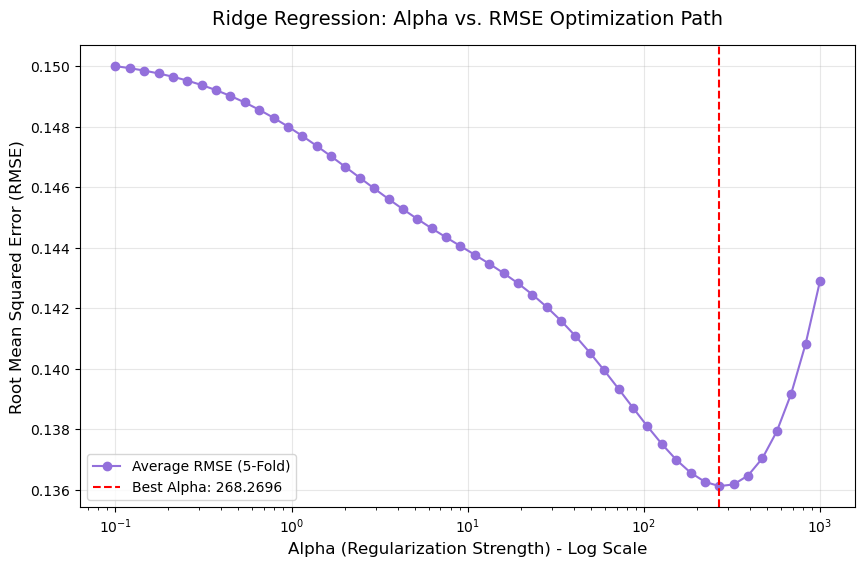

In [48]:
ridge_rmse_path = []

print("Computing Ridge RMSE across varying Alpha values, please wait...")

# 'ridge_alphas' refers to the previously defined search space: np.logspace(-1, 3, 50)
for a in ridge_alphas:
    model = Ridge(alpha=a)
    
    # Utilize the exact same K-Fold configuration (kf) to ensure a controlled and fair comparison
    scores = cross_val_score(model, X_dev_scaled, y_dev, cv=kf, scoring='neg_mean_squared_error')
    
    # Calculate the mean RMSE for the specific alpha and append to the results list
    mean_rmse = np.sqrt(np.abs(scores).mean())
    ridge_rmse_path.append(mean_rmse)

# ==========================================
# 2. Visualize the Alpha vs. RMSE Curve
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the relationship between Alpha and Average RMSE
plt.plot(ridge_alphas, ridge_rmse_path, marker='o', linestyle='-', color='mediumpurple', label='Average RMSE (5-Fold)')

# Indicate the "Best Alpha" previously identified by RidgeCV with a vertical dashed line
# This serves to verify that RidgeCV correctly targeted the minimum error point
plt.axvline(ridge_cv.alpha_, color='r', linestyle='--', label=f'Best Alpha: {ridge_cv.alpha_:.4f}')

# Set X-axis to logarithmic scale to reflect the exponential distribution of alpha values
plt.xscale('log')

plt.title('Ridge Regression: Alpha vs. RMSE Optimization Path', fontsize=14, pad=15)
plt.xlabel('Alpha (Regularization Strength) - Log Scale', fontsize=12)
plt.ylabel('Root Mean Squared Error (RMSE)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Comparative Analysis: Performance Evaluation of Regularized Linear Models

In [50]:
lasso_model.fit(X_dev_scaled, y_dev)

lasso_preds = lasso_model.predict(X_final_test_scaled)

lasso_test_rmse = rmse_log(y_final_test, lasso_preds)

ridge_model.fit(X_dev_scaled, y_dev)

ridge_preds = ridge_model.predict(X_final_test_scaled)

ridge_test_rmse = rmse_log(y_final_test, ridge_preds)

print("--- ( Test Error) ---")
print(f"Baseline Test RMSE (Log-Space): {baseline_test_rmse:.4f}")
print(f"Lasso Test RMSE (Log-Space): {lasso_test_rmse:.4f}")
print(f"Ridge Test RMSE (Log-Space): {ridge_test_rmse:.4f}")
print("="*40)
print(f"Basline Mean Percentage Error: {(np.exp(baseline_test_rmse) - 1)*100:.2f}%")
print(f"Lasso Mean Percentage Error: {(np.exp(lasso_test_rmse) - 1)*100:.2f}%")
print(f"Ridge Mean Percentage Error: {(np.exp(ridge_test_rmse) - 1)*100:.2f}%")

--- ( Test Error) ---
Baseline Test RMSE (Log-Space): 0.2445
Lasso Test RMSE (Log-Space): 0.1352
Ridge Test RMSE (Log-Space): 0.1421
Basline Mean Percentage Error: 27.69%
Lasso Mean Percentage Error: 14.48%
Ridge Mean Percentage Error: 15.27%


Diagnostic Visualization: Actual vs. Predicted Analysis for Lasso Regression

<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
/var/folders/l_/nv0813dj7fb6xj2x4dql_5ww0000gn/T/ipykernel_18687/1430088504.py:16: SyntaxWarning: invalid escape sequence '\h'
  label='Perfect Prediction ($y = \hat{y}$)')


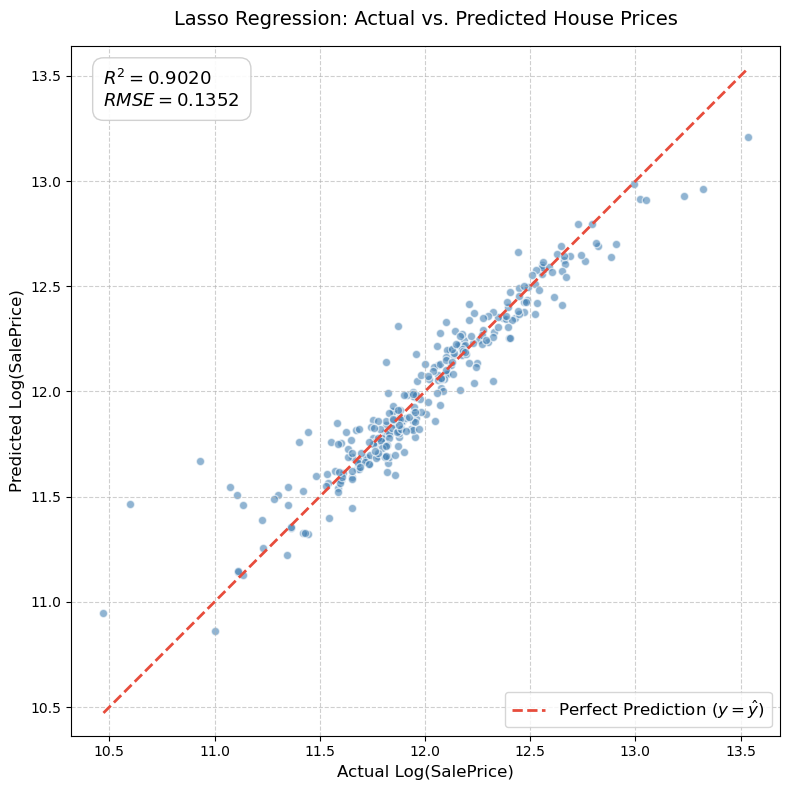

In [52]:
# 1. Compute evaluation metrics for Lasso on the Final Test set
lasso_r2 = r2_score(y_final_test, lasso_preds)
lasso_rmse = np.sqrt(mean_squared_error(y_final_test, lasso_preds))

plt.figure(figsize=(8, 8)) 

# 2. Plot prediction scatter points
plt.scatter(y_final_test, lasso_preds, alpha=0.6, color='steelblue', edgecolor='white')

# 3. Construct the 45-degree Identity Line (Perfect Prediction Line)
# This serves as the reference where Predicted (y_hat) exactly matches Actual (y)
min_val = min(np.min(y_final_test), np.min(lasso_preds))
max_val = max(np.max(y_final_test), np.max(lasso_preds))
plt.plot([min_val, max_val], [min_val, max_val], 
         color='#E74C3C', linestyle='--', linewidth=2, 
         label='Perfect Prediction ($y = \hat{y}$)')


plt.title('Lasso Regression: Actual vs. Predicted House Prices', fontsize=14, pad=15)
plt.xlabel('Actual Log(SalePrice)', fontsize=12)
plt.ylabel('Predicted Log(SalePrice)', fontsize=12)


plt.text(min_val, max_val, f'$R^2 = {lasso_r2:.4f}$\n$RMSE = {lasso_rmse:.4f}$',
         fontsize=13, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#ccc'))

# 6. Refine visual details and layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=12)


plt.axis('equal') 
plt.tight_layout()

plt.show()

Diagnostic Visualization: Actual vs. Predicted Analysis for Ridge Regression

<>:17: SyntaxWarning: invalid escape sequence '\h'
<>:17: SyntaxWarning: invalid escape sequence '\h'
/var/folders/l_/nv0813dj7fb6xj2x4dql_5ww0000gn/T/ipykernel_18687/2379865942.py:17: SyntaxWarning: invalid escape sequence '\h'
  label='Perfect Prediction ($y = \hat{y}$)')


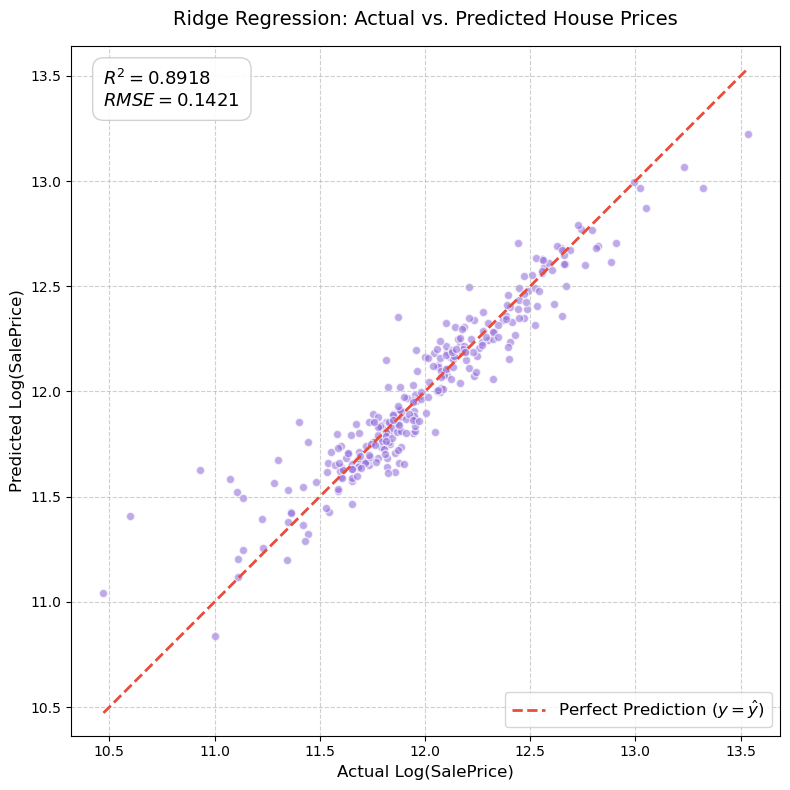

In [54]:
# 1. Compute evaluation metrics for Ridge on the Final Test set
ridge_r2 = r2_score(y_final_test, ridge_preds)
ridge_rmse = np.sqrt(mean_squared_error(y_final_test, ridge_preds))


plt.figure(figsize=(8, 8)) 

# 2. Plot prediction scatter points
plt.scatter(y_final_test, ridge_preds, alpha=0.6, color='mediumpurple', edgecolor='white')

# 3. Construct the 45-degree Identity Line (Perfect Prediction Line)
# This serves as the reference where Predicted (y_hat) exactly matches Actual (y)
min_val = min(np.min(y_final_test), np.min(ridge_preds))
max_val = max(np.max(y_final_test), np.max(ridge_preds))
plt.plot([min_val, max_val], [min_val, max_val], 
         color='#E74C3C', linestyle='--', linewidth=2, 
         label='Perfect Prediction ($y = \hat{y}$)')


plt.title('Ridge Regression: Actual vs. Predicted House Prices', fontsize=14, pad=15)
plt.xlabel('Actual Log(SalePrice)', fontsize=12)
plt.ylabel('Predicted Log(SalePrice)', fontsize=12)


plt.text(min_val, max_val, f'$R^2 = {ridge_r2:.4f}$\n$RMSE = {ridge_rmse:.4f}$',
         fontsize=13, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#ccc'))


plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=12)


plt.axis('equal') 
plt.tight_layout()

plt.show()

Feature Sparsity and Impact Analysis: Lasso Coefficient Interpretation

In [56]:
# ==========================================
# 1. Feature Extraction and DataFrame Construction
# ==========================================
features = X.columns
lasso_coefs = lasso_model.coef_

# Organize coefficients into a DataFrame for structured analysis
lasso_coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lasso_coefs,
    'Abs_Coefficient': np.abs(lasso_coefs)
})

# ==========================================
# 2. Feature Filtering: Identifying Retained vs. Eliminated Predictors
# ==========================================
# Lasso's L1 penalty performs automatic feature selection by zeroing out coefficients
lasso_dropped = lasso_coef_df[lasso_coef_df['Coefficient'] == 0]
lasso_kept = lasso_coef_df[lasso_coef_df['Coefficient'] != 0]

# ==========================================
# 3. Summary Report: Aggregate Statistics
# ==========================================
print("="*60)
print(" Lasso Feature Selection and Impact Report")
print("="*60)
print(f" Total Features in Dataset: {len(features)}")
print(f" Features Eliminated (Coefficients zeroed out): {len(lasso_dropped)}")
print(f" Features Retained (Predictive contributors): {len(lasso_kept)}")
print("-" * 60)

# ==========================================
# 4. Impact Analysis: Top 20 Most Influential Features
# ==========================================
if not lasso_kept.empty:
    # Rank by magnitude of absolute coefficient to identify strongest predictors
    top_20_lasso_features = lasso_kept.sort_values(by='Abs_Coefficient', ascending=False).head(20)
    print("\n Top 20 Most Influential Features on House Prices:")
    print(top_20_lasso_features[['Feature', 'Coefficient']].to_string(index=False))

print("\n" + "="*60)

 Lasso Feature Selection and Impact Report
 Total Features in Dataset: 250
 Features Eliminated (Coefficients zeroed out): 159
 Features Retained (Predictive contributors): 91
------------------------------------------------------------

 Top 20 Most Influential Features on House Prices:
             Feature  Coefficient
           GrLivArea     0.123166
         OverallQual     0.078564
           YearBuilt     0.052821
             LotArea     0.038679
         OverallCond     0.038552
          GarageCars     0.038293
          BsmtFinSF1     0.025310
Neighborhood_NridgHt     0.023488
        YearRemodAdd     0.020334
     Condition2_PosN    -0.018451
        BsmtFullBath     0.017177
            1stFlrSF     0.016792
Neighborhood_StoneBr     0.016510
      Functional_Typ     0.016455
          Fireplaces     0.016202
Neighborhood_Crawfor     0.015911
 Exterior1st_BrkFace     0.015481
     Condition1_Norm     0.013232
        CentralAir_Y     0.011982
         TotalBsmtSF     0.0116

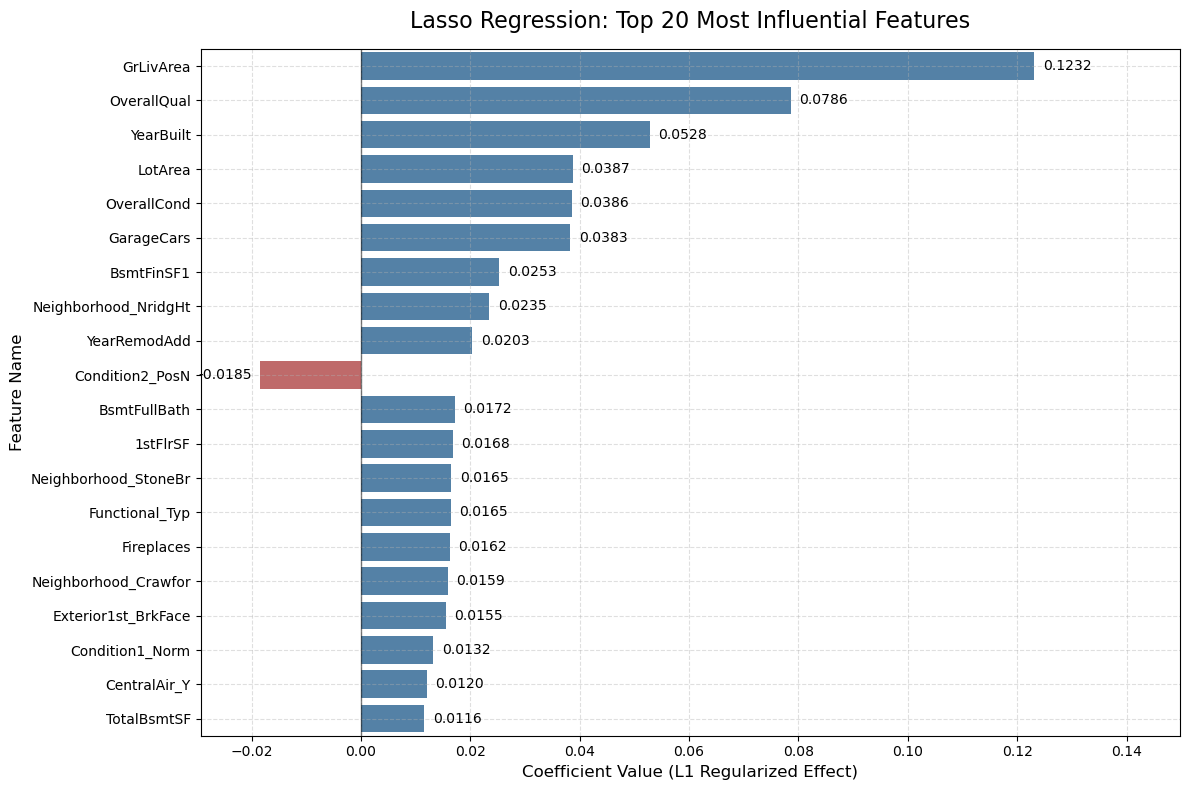

Lasso Model Summary Statistics:
1. Number of Retained Features: 91
2. Number of Automatically Eliminated Features: 159


In [57]:
# ==========================================
# 1. Prepare Plotting Data (Based on previously filtered top_20_lasso_features)
# ==========================================
# Rank features by their absolute magnitude to establish a clear visual hierarchy
lasso_plot_data = top_20_lasso_features.sort_values(by='Abs_Coefficient', ascending=False)

# Assign color categories: 'Pos' for positive correlation and 'Neg' for negative correlation
lasso_plot_data['Color'] = ['Pos' if x > 0 else 'Neg' for x in lasso_plot_data['Coefficient']]

# ==========================================
# 2. Generate Visualization
# ==========================================
plt.figure(figsize=(12, 8))

# Utilize hue to distinguish between the direction of influence
sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=lasso_plot_data,
    palette={'Pos': 'steelblue', 'Neg': 'indianred'},
    hue='Color',
    legend=False
)

plt.title('Lasso Regression: Top 20 Most Influential Features', fontsize=16, pad=15)
plt.xlabel('Coefficient Value (L1 Regularized Effect)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)


plt.axvline(x=0, color='black', linestyle='-', lw=1, alpha=0.5)

# ==========================================
# 3. Layout Refinement: Address Label Overlap and Clipping
# ==========================================
# 1. Retrieve current X-axis limits
x_min, x_max = plt.xlim()


plt.xlim(x_min * 1.15 if x_min < 0 else x_min, x_max * 1.15)

# 2. Calculate a dynamic offset (1% of the total X-range) for precise label spacing
offset = (x_max - x_min) * 0.01 

# 4. Apply numerical annotations with dynamic alignment based on the coefficient sign
for index, value in enumerate(lasso_plot_data['Coefficient']):
    if value > 0:
        # Positive values: text placed to the right, left-aligned
        plt.text(value + offset, index, f'{value:.4f}', va='center', ha='left', fontsize=10)
    else:
        # Negative values: text placed to the left, right-aligned
        plt.text(value - offset, index, f'{value:.4f}', va='center', ha='right', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()


plt.show()

print(f"Lasso Model Summary Statistics:")
print(f"1. Number of Retained Features: {len(lasso_kept)}")
print(f"2. Number of Automatically Eliminated Features: {len(lasso_dropped)}")

Feature Shrinkage and Impact Analysis: Ridge Coefficient Interpretation

In [59]:
# ==========================================
# 1. Initialize Ridge Coefficient DataFrame
# ==========================================
features = X.columns
ridge_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': ridge_model.coef_,
    'Abs_Coef': np.abs(ridge_model.coef_)
})

# ==========================================
# 2. Thresholding: Define the "Practical Zero" Limit
# ==========================================
# Since Ridge does not zero out weights like Lasso, we define a threshold (e.g., 1e-3)
# to distinguish between meaningful predictors and insignificant noise.
threshold = 0.001  

# Filter features based on the magnitude of their absolute coefficients
ridge_insignificant = ridge_df[ridge_df['Abs_Coef'] < threshold]
ridge_significant = ridge_df[ridge_df['Abs_Coef'] >= threshold]

# ==========================================
# 3. Summary Report: Thresholding Diagnostics
# ==========================================
print("="*60)
print(" Ridge Model: Practical Significance Analysis (Thresholding)")
print("="*60)
print(f" Total Features in Dataset: {len(features)}")
print(f" Defined Significance Threshold: {threshold}")
print(f" Insignificant Features (Magnitude < Threshold): {len(ridge_insignificant)}")
print(f" Substantially Significant Features (Magnitude >= Threshold): {len(ridge_significant)}")
print("-" * 60)

# ==========================================
# 4. Top 20 Most Influential Predictors
# ==========================================
# Ranking the "surviving" features with the highest impact
if not ridge_significant.empty:
    ridge_top20 = ridge_significant.sort_values(by='Abs_Coef', ascending=False).head(20)
    print("\n Top 20 Features with the Highest Substantial Impact:")
    print(ridge_top20[['Feature', 'Coefficient']].to_string(index=False))
print("="*60)

 Ridge Model: Practical Significance Analysis (Thresholding)
 Total Features in Dataset: 250
 Defined Significance Threshold: 0.001
 Insignificant Features (Magnitude < Threshold): 38
 Substantially Significant Features (Magnitude >= Threshold): 212
------------------------------------------------------------

 Top 20 Features with the Highest Substantial Impact:
             Feature  Coefficient
           GrLivArea     0.048980
         OverallQual     0.047840
            1stFlrSF     0.033533
         OverallCond     0.029084
             LotArea     0.025921
          GarageCars     0.024043
Neighborhood_NridgHt     0.021278
         TotalBsmtSF     0.020696
        YearRemodAdd     0.019867
        TotRmsAbvGrd     0.019344
Neighborhood_StoneBr     0.018920
        CentralAir_Y     0.017957
            FullBath     0.017855
           YearBuilt     0.017554
         BsmtQual_TA    -0.017371
            HalfBath     0.017233
Neighborhood_Crawfor     0.017099
          BsmtFinSF1  

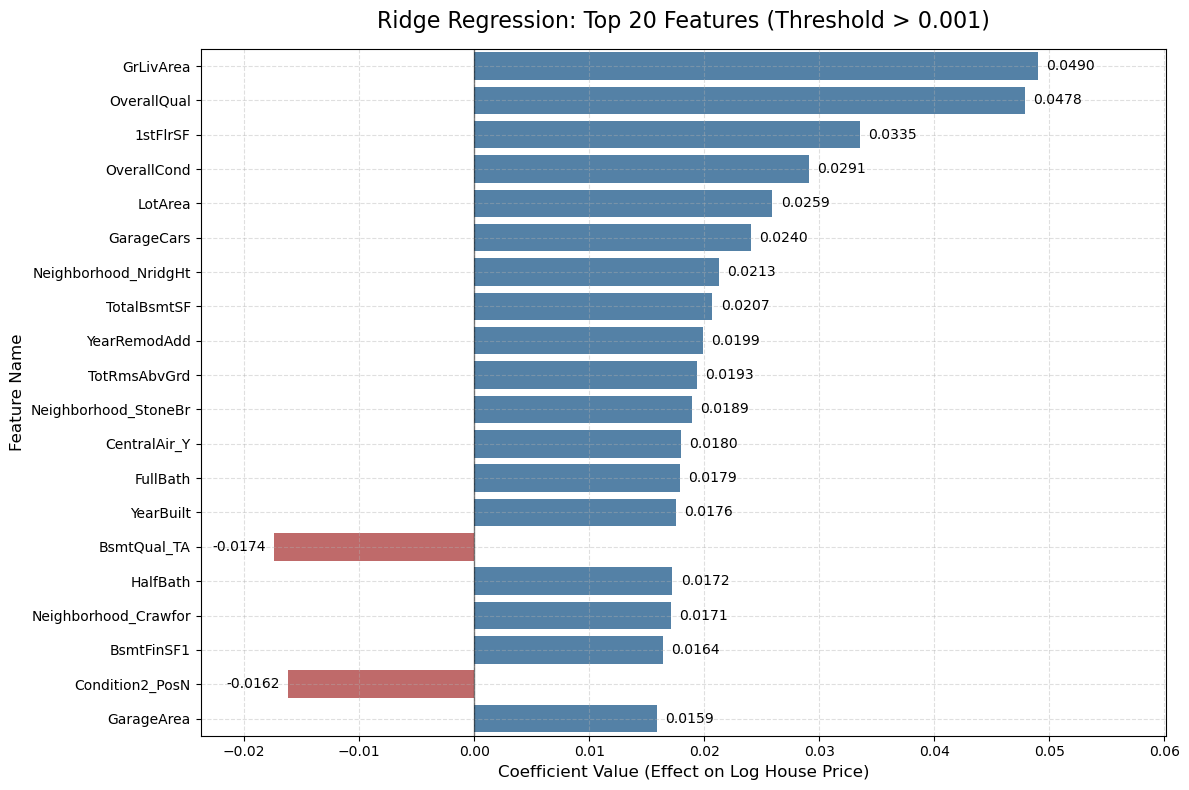

Interpretation Guide:
1. Blue Bars: Represent features with a positive correlation to house prices (value enhancers).
2. Red Bars: Represent features with a negative correlation to house prices (common for aging or damage).


In [60]:
# ==========================================
# 1. Prepare Visualization Data (Based on top_20_significant_ridge)
# ==========================================
# Isolate the top 20 features by their absolute magnitude to highlight the strongest predictors
ridge_plot_data = ridge_significant.sort_values(by='Abs_Coef', ascending=False).head(20)

# Categorize features by direction of influence for color mapping
# Positive values indicate an increase in price, while negative values indicate a decrease
ridge_plot_data['Color'] = ['Pos' if x > 0 else 'Neg' for x in ridge_plot_data['Coefficient']]

# ==========================================
# 2. Generate Visualization
# ==========================================
plt.figure(figsize=(12, 8))

# Utilize hue to distinguish between positive and negative predictive influence
sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=ridge_plot_data,
    palette={'Pos': 'steelblue', 'Neg': 'indianred'},
    hue='Color',
    legend=False
)

plt.title('Ridge Regression: Top 20 Features (Threshold > 0.001)', fontsize=16, pad=15)
plt.xlabel('Coefficient Value (Effect on Log House Price)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

# Add a zero-reference line to emphasize the center of the distribution
plt.axvline(x=0, color='black', linestyle='-', lw=1, alpha=0.5)

# ==========================================
# 3. Layout Refinement: Address Label Clipping and Alignment
# ==========================================
# 1. Retrieve current X-axis boundaries
x_min, x_max = plt.xlim()


plt.xlim(x_min * 1.15 if x_min < 0 else x_min, x_max * 1.15)

# 2. Calculate a dynamic offset (1% of the total X-range) for precise spacing
offset = (x_max - x_min) * 0.01 

# 3. Apply numerical labels with dynamic alignment based on the coefficient sign
for index, value in enumerate(ridge_plot_data['Coefficient']):
    if value > 0:
        # Positive coefficients: text placed to the right, left-aligned
        plt.text(value + offset, index, f'{value:.4f}', va='center', ha='left', fontsize=10)
    else:
        # Negative coefficients: text placed to the left, right-aligned
        plt.text(value - offset, index, f'{value:.4f}', va='center', ha='right', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

print("Interpretation Guide:")
print("1. Blue Bars: Represent features with a positive correlation to house prices (value enhancers).")
print("2. Red Bars: Represent features with a negative correlation to house prices (common for aging or damage).")

Non-Linear Ensemble Modeling: Hyperparameter Tuning for Gradient Boosting

In [62]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# 1. Define the Hyperparameter Grid for Optimization
param_grid = {
    'n_estimators': [500, 1000],        # Number of boosting stages (trees)
    'learning_rate': [0.01, 0.05, 0.1], # Step size shrinkage to prevent overfitting
    'max_depth': [3, 4, 5],             # Maximum depth of individual regression trees
    'subsample': [0.8, 0.9]             # Fraction of samples used for fitting individual base learners
}

# Initialize the base Gradient Boosting model
gb = GradientBoostingRegressor(random_state=42)

# 2. Configure GridSearchCV (Automated 5-Fold Cross-Validation)
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Utilize all available CPU cores for parallel processing
    verbose=2
)

print("Searching for the optimal hyperparameter combination. This may take several minutes...")
grid_search.fit(X_dev, y_dev)

# ==========================================
# 3. Cross-Validation (CV) Results Summary
# ==========================================
print("\n" + "-" * 40)
print(f" GB Optimal Parameters: {grid_search.best_params_}")
for key, value in grid_search.best_params_.items():
    # Standardize formatting: display floating-point values to 4 decimal places
    if isinstance(value, float) or type(value).__name__ == 'float64':
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# Extract the best cross-validation score stored during the grid search
gb_cv_rmse = np.sqrt(np.abs(grid_search.best_score_))
print(f" GB Mean CV RMSE (Validation Score): {gb_cv_rmse:.4f}")
print("-" * 40)

# 4. Final Evaluation on the Hold-out Test Set
best_gb_model = grid_search.best_estimator_

gb_final_preds = best_gb_model.predict(X_final_test)
gb_final_test_rmse = rmse_log(y_final_test, gb_final_preds)

print("\n" + "="*40)
print(" Gradient Boosting: Final Test Performance")
print("="*40)
print(f" GB Final Test RMSE: {gb_final_test_rmse:.4f}")
print(f" GB Mean Percentage Error:   {(np.exp(gb_final_test_rmse) - 1)*100:.2f}%")
print("=" * 40)

Searching for the optimal hyperparameter combination. This may take several minutes...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

----------------------------------------
 GB Optimal Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.9}
  learning_rate: 0.0500
  max_depth: 3
  n_estimators: 1000
  subsample: 0.9000
 GB Mean CV RMSE (Validation Score): 0.1264
----------------------------------------

 Gradient Boosting: Final Test Performance
 GB Final Test RMSE: 0.1355
 GB Mean Percentage Error:   14.52%


Stochastic Optimization: Randomized Search for Gradient Boosting Regressor

In [64]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import randint, uniform
import numpy as np

# ==========================================
# 1. Define Continuous Parameter Distributions
# ==========================================
# We define probability distributions for each hyperparameter to allow 
# for a more flexible and exhaustive search of the parameter space.
param_dist = {
    'n_estimators': randint(300, 1500),
    'learning_rate': uniform(0.01, 0.09),
    'max_depth': randint(3, 8),
    'subsample': uniform(0.6, 0.4),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

gb = GradientBoostingRegressor(random_state=42)

# ==========================================
# 2. Initialize the RandomizedSearchCV Object
# ==========================================
random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter=20,             # Randomly sample 20 different combinations
    cv=kf,                  # Perform 5-Fold Cross-Validation for each iteration
    scoring='neg_mean_squared_error',
    n_jobs=-1,              # Utilize all available CPU cores
    verbose=2,
    random_state=42
)

print("Performing 100 iterations of randomized search. This may take some time...")
random_search.fit(X_dev, y_dev)


# ==========================================
# 3. Summary of Cross-Validation (CV) Results
# ==========================================
print("\n" + "-" * 40)
print(" GB Randomized Search: Optimal Parameters")
for key, value in random_search.best_params_.items():
    if isinstance(value, float) or type(value).__name__ == 'float64':
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")
print("-" * 40)

# ==========================================
# 4. Rigorous Model Evaluation (Variance Assessment)
# ==========================================
# 1. Isolate the champion model identified by the search
best_gb_random_model = random_search.best_estimator_

# 2. Re-evaluate the champion model using rigorous CV standards
print("Re-calculating CV RMSE for the model using rigorous metrics...")
gb_cv_scores = cross_val_score(best_gb_random_model, X_dev, y_dev, cv=kf, scoring='neg_mean_squared_error')

# 3. Apply the specific scoring logic: Calculate individual Fold RMSE first, 
# then derive the mean and standard deviation to assess stability.
gb_fold_rmses = np.sqrt(np.abs(gb_cv_scores))
gb_mean_rmse = gb_fold_rmses.mean()
gb_std_rmse = gb_fold_rmses.std()

print(f" GB Rigorous Mean RMSE (CV Score): {gb_mean_rmse:.4f} (± {gb_std_rmse:.4f})")
print("-" * 40)

# 5. Final Prediction on the Hold-out Test Set
gb_random_final_preds = best_gb_random_model.predict(X_final_test)
gb_random_final_test_rmse = rmse_log(y_final_test, gb_random_final_preds)

print("\n" + "="*45)
print(" RandomizedSearchCV: GB Final Test Results")
print("="*45)
print(f" GB (Random Search) Test RMSE (Log-Space): {gb_random_final_test_rmse:.4f}")
print(f" GB (Random Search) Mean Percentage Error:          {(np.exp(gb_random_final_test_rmse) - 1)*100:.2f}%")
print("=" * 45)

Performing 100 iterations of randomized search. This may take some time...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

----------------------------------------
 GB Randomized Search: Optimal Parameters
  learning_rate: 0.0249
  max_depth: 3
  min_samples_leaf: 7
  min_samples_split: 10
  n_estimators: 1452
  subsample: 0.6795
----------------------------------------
Re-calculating CV RMSE for the model using rigorous metrics...
 GB Rigorous Mean RMSE (CV Score): 0.1249 (± 0.0153)
----------------------------------------

 RandomizedSearchCV: GB Final Test Results
 GB (Random Search) Test RMSE (Log-Space): 0.1318
 GB (Random Search) Mean Percentage Error:          14.08%


Performance Benchmark: From Linear Baselines to Initial Ensembles

In [66]:
print(f"Basline Mean Percentage Error: {(np.exp(baseline_test_rmse) - 1)*100:.2f}%")
print(f"Lasso Mean Percentage Error: {(np.exp(lasso_test_rmse) - 1)*100:.2f}%")
print(f"Ridge Mean Percentage Error: {(np.exp(ridge_test_rmse) - 1)*100:.2f}%")
print(f"GB (Grid Search) Mean Percentage Error: {(np.exp(gb_final_test_rmse) - 1)*100:.2f}%")
print(f"GB (Random Search) Mean Percentage Error: {(np.exp(gb_random_final_test_rmse) - 1)*100:.2f}%")

Basline Mean Percentage Error: 27.69%
Lasso Mean Percentage Error: 14.48%
Ridge Mean Percentage Error: 15.27%
GB (Grid Search) Mean Percentage Error: 14.52%
GB (Random Search) Mean Percentage Error: 14.08%


Stability Analysis: Cross-Validation Performance for Gradient Boosting

Mean RMSE: 0.1249 ± 0.0153


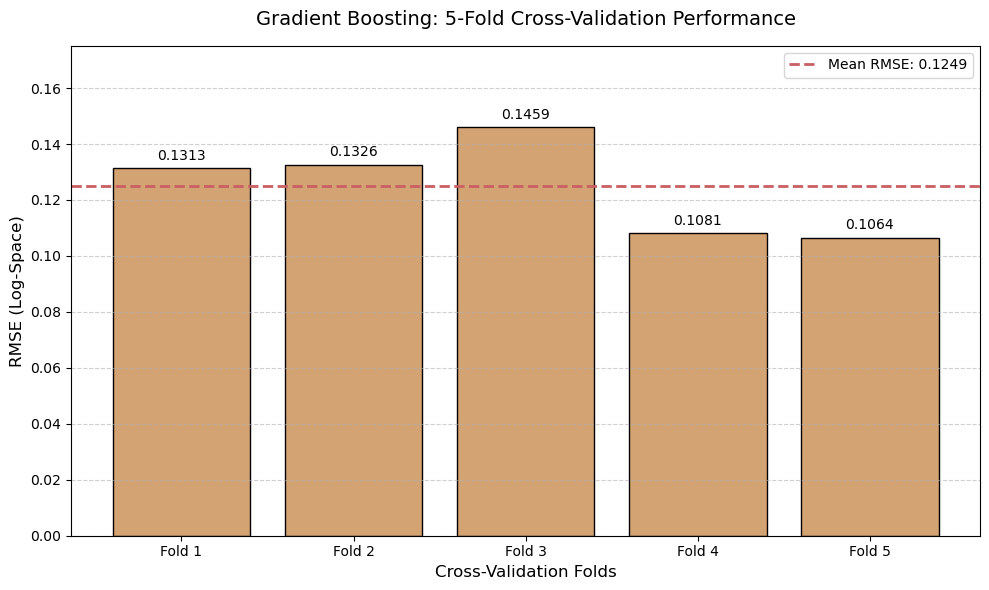

In [68]:
# 1. Retrieve the index of the optimal hyperparameter combination
best_index = random_search.best_index_

# 2. Extract independent scores for the best model across the 5 folds
n_splits = 5
fold_scores = []

for i in range(n_splits):
    # Extract the negative MSE, convert to positive, and calculate the square root to get RMSE
    mse_score = -random_search.cv_results_[f'split{i}_test_score'][best_index]
    rmse_score = np.sqrt(mse_score)
    fold_scores.append(rmse_score)

# 3. Compute the mean and standard deviation to evaluate model variance and stability
mean_rmse = np.mean(fold_scores)
std_rmse = np.std(fold_scores)
print(f"Mean RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")

# 4. Generate visualization (consistent with the previous Lasso/Ridge bar chart styles)
folds_labels = [f'Fold {i+1}' for i in range(n_splits)]

plt.figure(figsize=(10, 6))
# Using a distinct color (#D4A373) to differentiate the Ensemble model from linear variants
bars = plt.bar(folds_labels, fold_scores, color="#D4A373", edgecolor='black')

# Overlay a red dashed line representing the Mean RMSE as a benchmark
plt.axhline(y=mean_rmse, color='#c95f62', linestyle='--', linewidth=2, 
            label=f'Mean RMSE: {mean_rmse:.4f}')

# Annotate each bar with its precise RMSE value for granular inspection
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, 
             f'{yval:.4f}', ha='center', va='bottom')

# Configure chart aesthetics and layout
plt.title('Gradient Boosting: 5-Fold Cross-Validation Performance', fontsize=14, pad=15)
plt.ylabel('RMSE (Log-Space)', fontsize=12)
plt.xlabel('Cross-Validation Folds', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, max(fold_scores) * 1.2) 
plt.legend()
plt.tight_layout()

plt.show()

Diagnostic Visualization: Actual vs. Predicted Analysis for Gradient Boosting

<>:17: SyntaxWarning: invalid escape sequence '\h'
<>:17: SyntaxWarning: invalid escape sequence '\h'
/var/folders/l_/nv0813dj7fb6xj2x4dql_5ww0000gn/T/ipykernel_18687/1062223219.py:17: SyntaxWarning: invalid escape sequence '\h'
  label='Perfect Prediction ($y = \hat{y}$)')


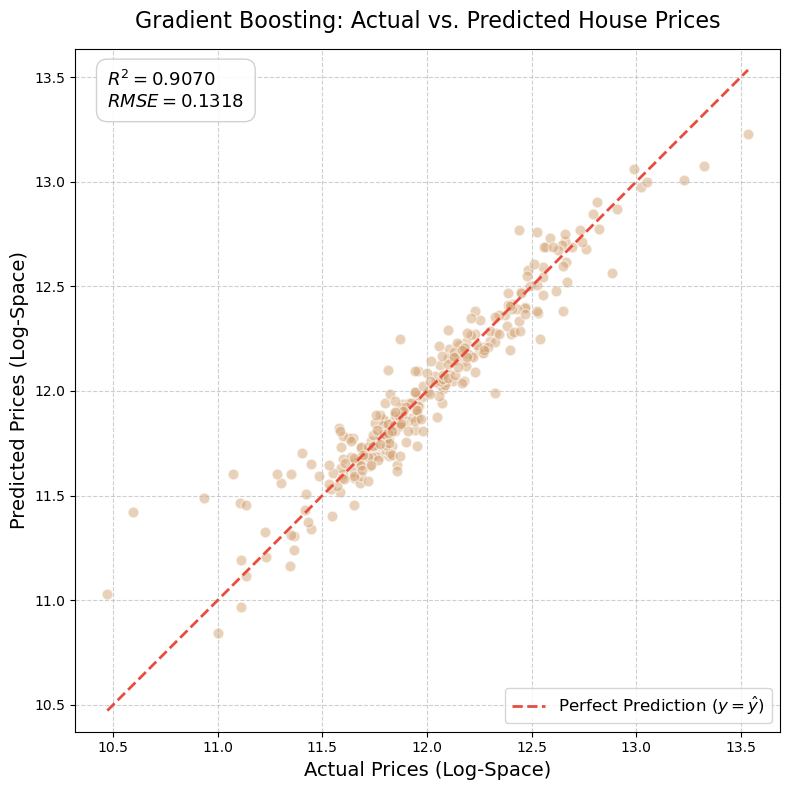

In [70]:
# 1. Calculate evaluation metrics for the tuned Gradient Boosting model
r2 = r2_score(y_final_test, gb_random_final_preds)
rmse = np.sqrt(mean_squared_error(y_final_test, gb_random_final_preds))

# 2. Initialize visualization
plt.figure(figsize=(8, 8)) 

# Generate the scatter plot of actual vs. predicted values
plt.scatter(y_final_test, gb_random_final_preds, 
            alpha=0.5, color="#D4A373", edgecolor='white', s=60)

# 3. Construct the y=x "Perfect Prediction" reference line
min_val = min(np.min(y_final_test), np.min(gb_random_final_preds))
max_val = max(np.max(y_final_test), np.max(gb_random_final_preds))
plt.plot([min_val, max_val], [min_val, max_val], 
         color='#E74C3C', linestyle='--', linewidth=2, 
         label='Perfect Prediction ($y = \hat{y}$)')

# 4. Configure plot labels and formatting
plt.title('Gradient Boosting: Actual vs. Predicted House Prices', fontsize=16, pad=15)
plt.xlabel('Actual Prices (Log-Space)', fontsize=14)
plt.ylabel('Predicted Prices (Log-Space)', fontsize=14)

# 5. Add a text box containing evaluation metrics in the upper-left corner
plt.text(min_val, max_val, f'$R^2 = {r2:.4f}$\n$RMSE = {rmse:.4f}$',
         fontsize=13, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#ccc'))

# 6. Refine visual aesthetics
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=12)

plt.axis('equal') 
plt.tight_layout()

plt.show()

Model Complexity Analysis: Validation Curve for Max Depth

Calculating validation curve for max_depth. This requires 50 training iterations. Please wait...


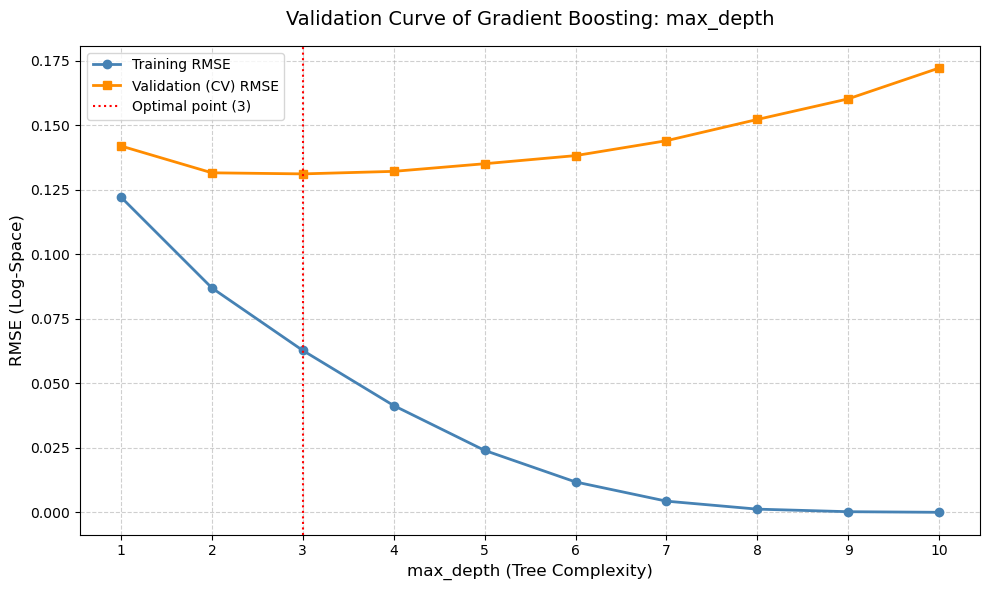

In [72]:
from sklearn.model_selection import validation_curve

# 1. Define the target parameter and its observation range
# We observe the performance transition as max_depth increases from 1 to 10
param_name = "max_depth"
param_range = np.arange(1, 11)

# 2. Initialize the base estimator
# Other hyperparameters are fixed at reasonable values to isolate the effect of depth.
# A slightly higher learning_rate is used here to accelerate the computation.
gb_base = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42)


print(f"Calculating validation curve for {param_name}. This requires {len(param_range)*5} training iterations. Please wait...")

# 3. Utilize the sklearn validation_curve utility
# Note: Evaluation is strictly performed on the development set (X_dev, y_dev)
train_scores, test_scores = validation_curve(
    estimator=gb_base,
    X=X_dev,       
    y=y_dev,
    param_name=param_name,
    param_range=param_range,
    cv=kf,         # Using 5-Fold Cross-Validation
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# 4. Metric Conversion
# Transforming negative MSE results into mean RMSE for intuitive interpretation
train_rmse = np.sqrt(np.abs(train_scores)).mean(axis=1)
test_rmse = np.sqrt(np.abs(test_scores)).mean(axis=1)

# ==========================================
# 5. Generate Professional Diagnostic Visualization
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Training RMSE curve
plt.plot(param_range, train_rmse, label="Training RMSE", color="steelblue", marker='o', lw=2)

# Plot Validation (CV) RMSE curve
plt.plot(param_range, test_rmse, label="Validation (CV) RMSE", color="darkorange", marker='s', lw=2)

plt.title("Validation Curve of Gradient Boosting: max_depth", fontsize=14, pad=15)
plt.xlabel("max_depth (Tree Complexity)", fontsize=12)
plt.ylabel("RMSE (Log-Space)", fontsize=12)

# Refine aesthetics for technical reporting
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(param_range)
plt.legend(loc="best", fontsize=11)

# Indicate the optimal complexity threshold (e.g., depth of 3)
plt.axvline(x=3, color='red', linestyle=':', label='Optimal point (3)')
plt.legend(loc="best")

plt.tight_layout()
plt.show()

Underfitting is observed for max_depth values below 3. The validation error plateaus between 2 and 4; however, as the depth exceeds 4, the error begins to rise, indicating the onset of overfitting.

Model Complexity Analysis: Validation Curve for N-Estimators

Calculating validation curve for n_estimators. This process may take a few minutes...


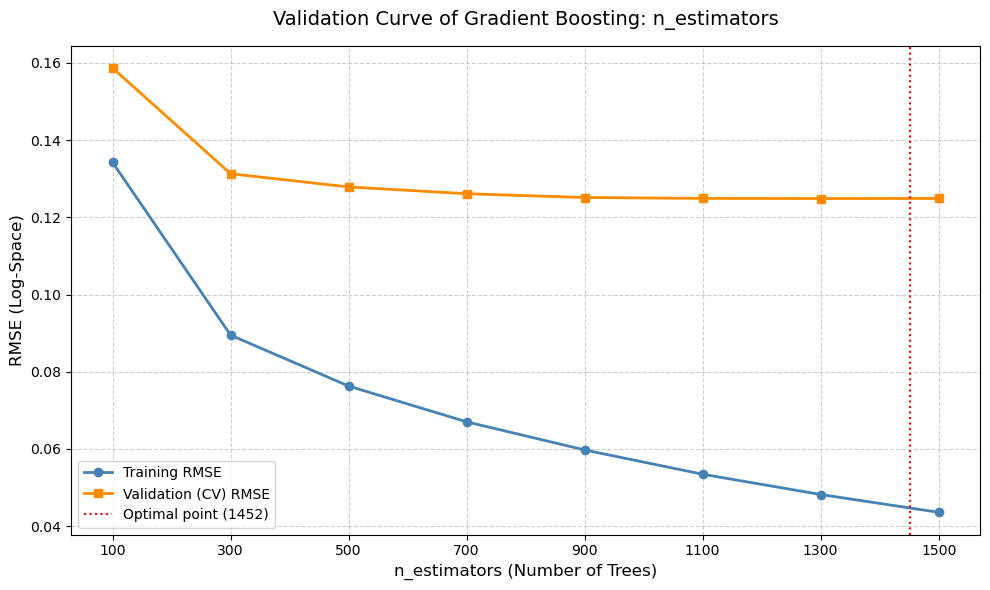

In [75]:
# 1. Define the target parameter and range (from 100 to 1500 trees, step 200)
param_name = "n_estimators"
param_range = np.arange(100, 1600, 200)

# 2. Initialize the base estimator
# CRITICAL: Freeze other hyperparameters at the previously identified "optimal values"
gb_base = GradientBoostingRegressor(
    learning_rate=0.0249, 
    max_depth=3,
    min_samples_leaf=7,
    min_samples_split=10,
    subsample=0.6795,
    random_state=42
)

print(f"Calculating validation curve for {param_name}. This process may take a few minutes...")

# 3. Call the sklearn validation_curve utility
train_scores, test_scores = validation_curve(
    estimator=gb_base,
    X=X_dev,
    y=y_dev,
    param_name=param_name,
    param_range=param_range,
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# 4. Metric Conversion
# Transforming negative MSE results into mean RMSE for intuitive interpretation
train_rmse = np.sqrt(np.abs(train_scores)).mean(axis=1)
test_rmse = np.sqrt(np.abs(test_scores)).mean(axis=1)

# ==========================================
# 5. Generate Professional Diagnostic Visualization
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Training RMSE
plt.plot(param_range, train_rmse, label="Training RMSE", color="steelblue", marker='o', lw=2)
# Plot Validation (CV) RMSE
plt.plot(param_range, test_rmse, label="Validation (CV) RMSE", color="darkorange", marker='s', lw=2)

plt.title("Validation Curve of Gradient Boosting: n_estimators", fontsize=14, pad=15)
plt.xlabel("n_estimators (Number of Trees)", fontsize=12)
plt.ylabel("RMSE (Log-Space)", fontsize=12)

# Refine aesthetics for technical reporting
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(param_range)
plt.legend(loc="best", fontsize=11)

# Indicate the previously identified optimal point (1308) with a vertical line
plt.axvline(x=1452, color='red', linestyle=':', label='Optimal point (1452)')
plt.legend(loc="best")

plt.tight_layout()
plt.show()

Regularization Analysis: Validation Curve for Min Samples Leaf

Calculating validation curve for min_samples_leaf. Please wait...


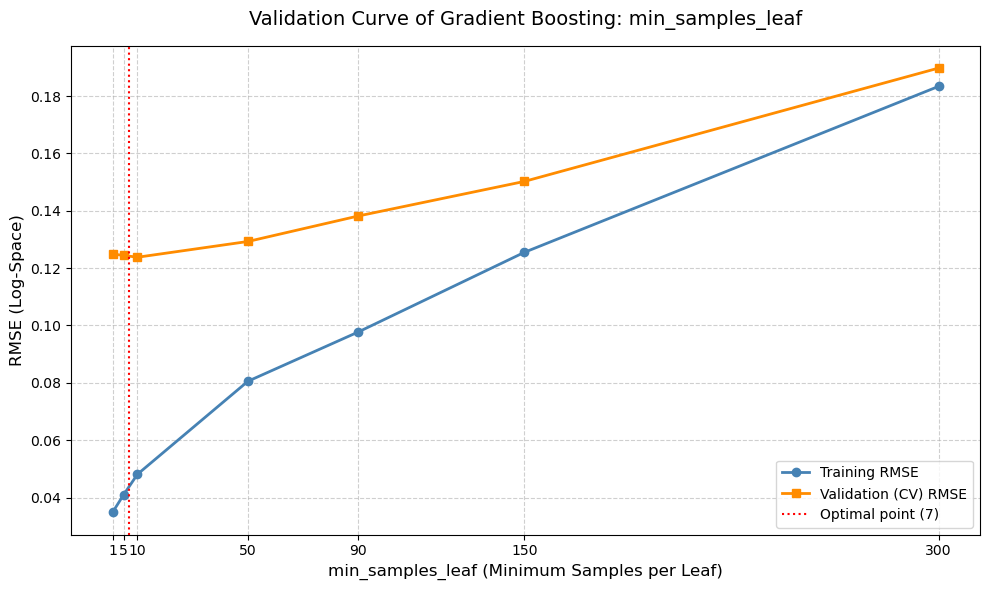

In [77]:
# 1. Define the observation range: Minimum samples per leaf node
param_name = "min_samples_leaf"
# Considering max_depth=3 and a development set of ~1168 samples,
# each leaf captures roughly 146 samples on average. We explore a wide range to find the optimal constraint.
param_range = np.array([1, 5, 10, 50, 90, 150, 300]) 

# 2. Initialize the Base Estimator
# Fixed hyperparameters are set based on previous optimization results.
gb_base = GradientBoostingRegressor(
    n_estimators=1452,       
    learning_rate=0.0249, 
    max_depth=3,
    min_samples_split=10,
    subsample=0.6795,
    random_state=42
)

print(f"Calculating validation curve for {param_name}. Please wait...")

# 3. Invoke the validation_curve utility
train_scores, test_scores = validation_curve(
    estimator=gb_base,
    X=X_dev,
    y=y_dev,
    param_name=param_name,
    param_range=param_range,
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# 4. Metric Conversion
# Transforming negative MSE results into mean RMSE for standardized evaluation
train_rmse = np.sqrt(np.abs(train_scores)).mean(axis=1)
test_rmse = np.sqrt(np.abs(test_scores)).mean(axis=1)

# ==========================================
# 5. Generate Professional Diagnostic Visualization
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Training and Validation RMSE curves
plt.plot(param_range, train_rmse, label="Training RMSE", color="steelblue", marker='o', lw=2)
plt.plot(param_range, test_rmse, label="Validation (CV) RMSE", color="darkorange", marker='s', lw=2)

plt.title("Validation Curve of Gradient Boosting: min_samples_leaf", fontsize=14, pad=15)
plt.xlabel("min_samples_leaf (Minimum Samples per Leaf)", fontsize=12)
plt.ylabel("RMSE (Log-Space)", fontsize=12)

# Refine chart aesthetics for reporting
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(param_range)
plt.legend(loc="best", fontsize=11)

# Indicate the previously identified optimal point (7) with a vertical line
plt.axvline(x=7, color='red', linestyle=':', label='Optimal point (7)')
plt.legend(loc="best")

plt.tight_layout()
plt.show()

Model Optimization: Validation Curve for Learning Rate

Calculating the validation curve for learning_rate. This may take a few minutes, please wait...


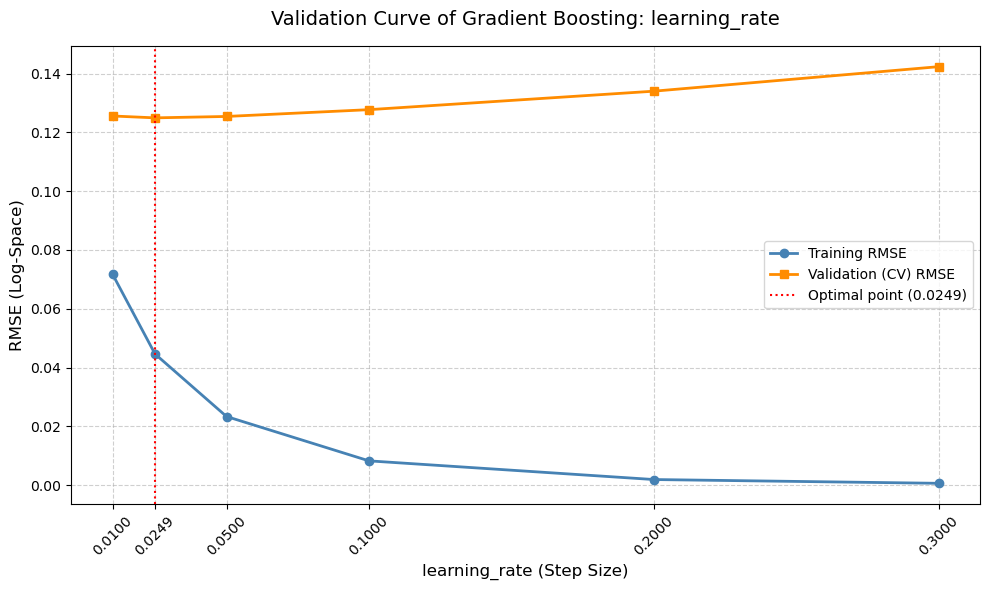

In [79]:
# 1. Define the observation range: Learning Rate (from very small 0.01 to larger 0.3)
param_name = "learning_rate"
# We test these specific key points: 0.01, 0.0249 (your optimal point), 0.05, 0.1, 0.2, and 0.3
param_range = np.array([0.01, 0.0249, 0.05, 0.1, 0.2, 0.3])

# 2. Initialize the Base Estimator
# CRITICAL: Lock other parameters to the optimal values previously identified:
# 1452 trees, max depth of 3, and a leaf constraint of 7.
gb_base = GradientBoostingRegressor(
    n_estimators=1452,       
    max_depth=3,
    min_samples_leaf=7,
    min_samples_split=10,
    subsample=0.6795,
    random_state=42
)

print(f"Calculating the validation curve for {param_name}. This may take a few minutes, please wait...")

# 3. Call the sklearn validation_curve utility
train_scores, test_scores = validation_curve(
    estimator=gb_base,
    X=X_dev,
    y=y_dev,
    param_name=param_name,
    param_range=param_range,
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# 4. Metric Conversion
# Transform negative MSE scores into RMSE for intuitive interpretation
train_rmse = np.sqrt(np.abs(train_scores)).mean(axis=1)
test_rmse = np.sqrt(np.abs(test_scores)).mean(axis=1)

# ==========================================
# 5. Generate Professional Diagnostic Visualization
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Training and Validation RMSE curves
plt.plot(param_range, train_rmse, label="Training RMSE", color="steelblue", marker='o', lw=2)
plt.plot(param_range, test_rmse, label="Validation (CV) RMSE", color="darkorange", marker='s', lw=2)

plt.title("Validation Curve of Gradient Boosting: learning_rate", fontsize=14, pad=15)
plt.xlabel("learning_rate (Step Size)", fontsize=12)
plt.ylabel("RMSE (Log-Space)", fontsize=12)

# Refine chart aesthetics for reporting
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(param_range, rotation=45)

# Add a vertical dashed line to indicate the previously identified optimal point (0.0249)
plt.axvline(x=0.0249, color='red', linestyle=':', label='Optimal point (0.0249)')
plt.legend(loc="best")

plt.tight_layout()
plt.show()

Model Optimization: Validation Curve for Subsample

Calculating the validation curve for 'subsample'. Please wait...


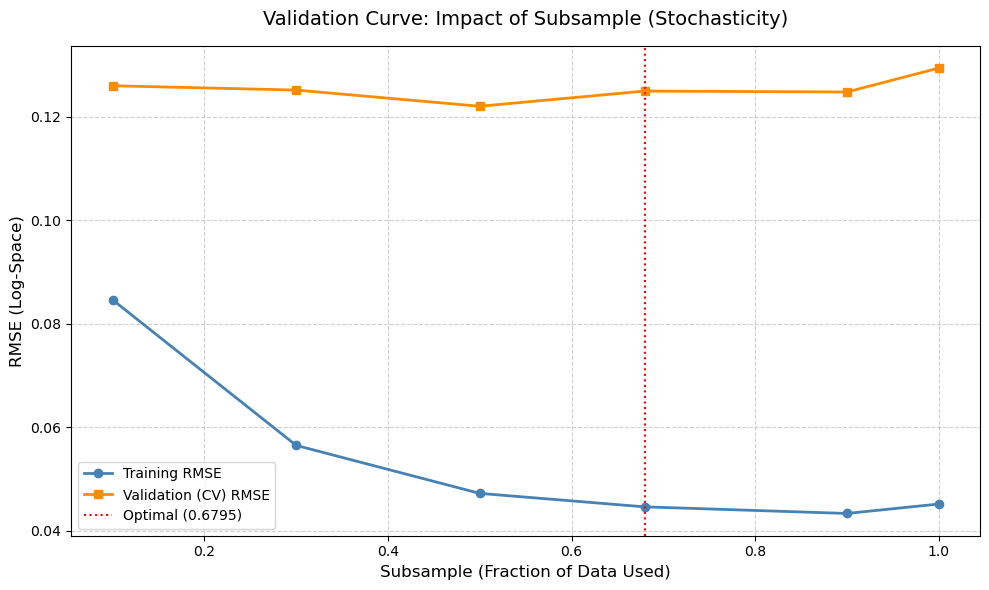

In [81]:
# 1. Initialize the Base Estimator 
gb_base_sub = GradientBoostingRegressor(
    n_estimators=1452, 
    learning_rate=0.0249, 
    max_depth=3, 
    min_samples_leaf=7,
    random_state=42
)

# 2. Define the Test Range (from 10% to 100% of the training data)
param_range_subsample = np.array([0.1, 0.3, 0.5, 0.6795, 0.9, 1.0])

print("Calculating the validation curve for 'subsample'. Please wait...")

# 3. Compute Validation Curve scores
# Note: Evaluation is performed using 5-Fold Cross-Validation on the development set.
train_scores_sub, test_scores_sub = validation_curve(
    estimator=gb_base_sub, 
    X=X_dev, y=y_dev, 
    param_name="subsample",
    param_range=param_range_subsample, 
    cv=kf, scoring="neg_mean_squared_error", n_jobs=-1
)

# 4. Metric Conversion
# Convert negative MSE scores into mean RMSE for intuitive analysis.
train_rmse_sub = np.sqrt(np.abs(train_scores_sub)).mean(axis=1)
test_rmse_sub = np.sqrt(np.abs(test_scores_sub)).mean(axis=1)

# ==========================================
# 5. Generate Professional Diagnostic Visualization
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Training and Validation RMSE curves
plt.plot(param_range_subsample, train_rmse_sub, label="Training RMSE", color="steelblue", marker='o', lw=2)
plt.plot(param_range_subsample, test_rmse_sub, label="Validation (CV) RMSE", color="darkorange", marker='s', lw=2)

plt.title("Validation Curve: Impact of Subsample (Stochasticity)", fontsize=14, pad=15)
plt.xlabel("Subsample (Fraction of Data Used)", fontsize=12)
plt.ylabel("RMSE (Log-Space)", fontsize=12)

# Refine chart aesthetics for reporting
plt.grid(True, linestyle='--', alpha=0.6)

# Indicate the previously identified optimal point (0.7246)
plt.axvline(x=0.6795, color='red', linestyle=':', label='Optimal (0.6795)')
plt.legend(loc="best")
plt.tight_layout()
plt.show()

Model Optimization: Validation Curve for Min Samples Split

Calculating the validation curve for 'min_samples_split'. Please wait...


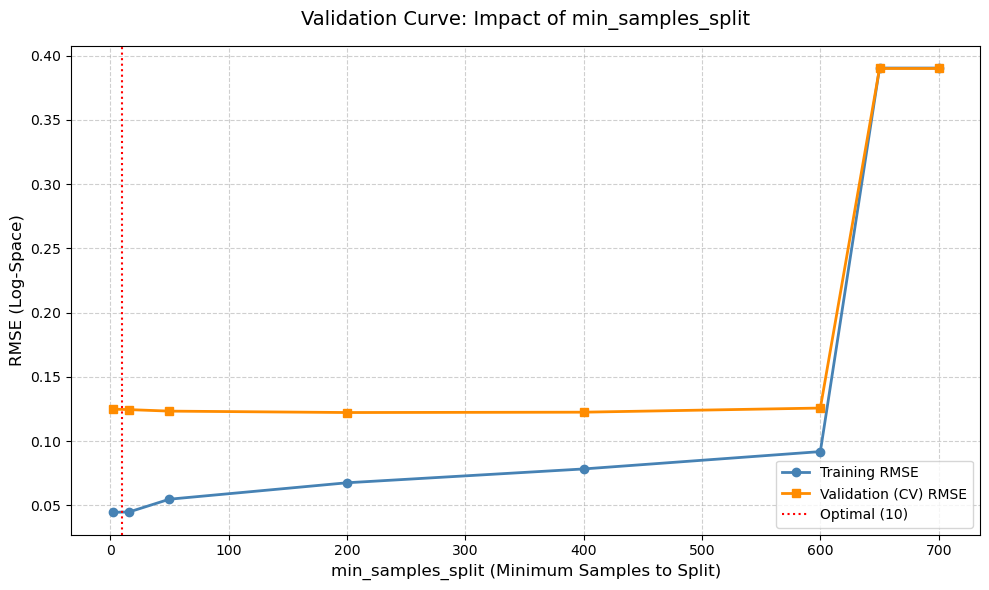

In [83]:
from sklearn.model_selection import validation_curve
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize the Base Estimator
# Configured with previously optimized hyperparameters: 
gb_base_split = GradientBoostingRegressor(
    n_estimators=1452, 
    learning_rate=0.0249, 
    max_depth=3, 
    min_samples_leaf=7,
    subsample=0.6795, 
    random_state=42
)

# 2. Define the Test Range (Evaluating a range from 2 to 700 samples)
param_range_split = np.array([2, 16, 50, 200, 400, 600, 650, 700])

print("Calculating the validation curve for 'min_samples_split'. Please wait...")

# 3. Compute Validation Curve scores
# Evaluation is performed using 5-Fold Cross-Validation on the development set.
train_scores_split, test_scores_split = validation_curve(
    estimator=gb_base_split, 
    X=X_dev, y=y_dev, 
    param_name="min_samples_split",
    param_range=param_range_split, 
    cv=kf, scoring="neg_mean_squared_error", n_jobs=-1
)

# 4. Metric Conversion
# Transform negative MSE results into mean RMSE for standardized interpretation.
train_rmse_split = np.sqrt(np.abs(train_scores_split)).mean(axis=1)
test_rmse_split = np.sqrt(np.abs(test_scores_split)).mean(axis=1)

# ==========================================
# 5. Generate Professional Diagnostic Visualization
# ==========================================
plt.figure(figsize=(10, 6))

# Plot Training and Validation RMSE curves
plt.plot(param_range_split, train_rmse_split, label="Training RMSE", color="steelblue", marker='o', lw=2)
plt.plot(param_range_split, test_rmse_split, label="Validation (CV) RMSE", color="darkorange", marker='s', lw=2)

plt.title("Validation Curve: Impact of min_samples_split", fontsize=14, pad=15)
plt.xlabel("min_samples_split (Minimum Samples to Split)", fontsize=12)
plt.ylabel("RMSE (Log-Space)", fontsize=12)

# Refine chart aesthetics for technical reporting
plt.grid(True, linestyle='--', alpha=0.6)

# Indicate the previously identified optimal point (10) with a vertical line
plt.axvline(x=10, color='red', linestyle=':', label='Optimal (10)')
plt.legend(loc="best")
plt.tight_layout()
plt.show()

Feature Importance Analysis: Identifying Key Predictors in the Gradient Boosting Ensemble

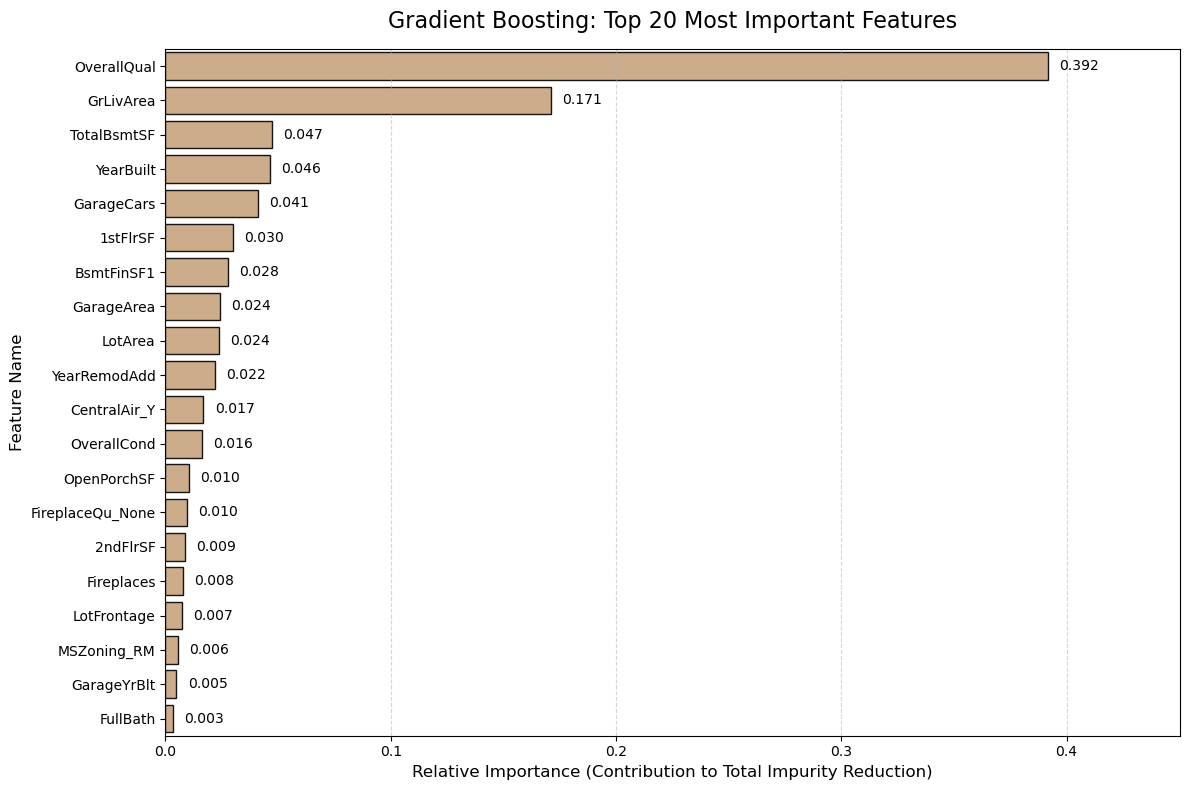


 Ensemble Analysis: Top 5 Critical Features
------------------------------------------------------------
  1. OverallQual               (Weight: 0.392)
  2. GrLivArea                 (Weight: 0.171)
  3. TotalBsmtSF               (Weight: 0.047)
  4. YearBuilt                 (Weight: 0.046)
  5. GarageCars                (Weight: 0.041)


In [85]:
# ==========================================
# 1. Extract Feature Importances
# ==========================================
# Retrieve the Gini importance (Mean Decrease in Impurity) from the optimized ensemble model
importances = best_gb_random_model.feature_importances_
feature_names = X_dev.columns

# ==========================================
# 2. Organize and Rank Features
# ==========================================
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
top_20_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(20)

# ==========================================
# 3. Generate High-Resolution Visualization
# ==========================================
plt.figure(figsize=(12, 8))


sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_20_features,
    color='#D4A373',     
    edgecolor='black',    
    alpha=0.9 
)

plt.title('Gradient Boosting: Top 20 Most Important Features', fontsize=16, pad=15)
plt.xlabel('Relative Importance (Contribution to Total Impurity Reduction)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

# Add vertical gridlines aligned with previous linear model visualizations
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Annotate bars with precise importance values
for index, value in enumerate(top_20_features['Importance']):
    plt.text(value + 0.005, index, f'{value:.3f}', va='center', fontsize=10)

plt.xlim(0, max(top_20_features['Importance']) * 1.15)
plt.tight_layout()


plt.show()

# ==========================================
# 4. Summary of Top 5 Dominant Predictors
# ==========================================
print("\n" + "="*60)
print(" Ensemble Analysis: Top 5 Critical Features")
print("-" * 60)
for i, (feat, imp) in enumerate(zip(top_20_features['Feature'].head(5), top_20_features['Importance'].head(5))):
    print(f"  {i+1}. {feat:<25} (Weight: {imp:.3f})")
print("="*60)

Hybrid model (Lasso + GBR)

Initiating rigorous K-Fold CV to identify the optimal Hybrid weights...

Testing Weight -> Lasso: 0.0 | GBR: 1.0 ==> CV RMSE: 0.12486 (± 0.01525)
Testing Weight -> Lasso: 0.1 | GBR: 0.9 ==> CV RMSE: 0.12346 (± 0.01561)
Testing Weight -> Lasso: 0.2 | GBR: 0.8 ==> CV RMSE: 0.12254 (± 0.01598)
Testing Weight -> Lasso: 0.3 | GBR: 0.7 ==> CV RMSE: 0.12210 (± 0.01637)
Testing Weight -> Lasso: 0.4 | GBR: 0.6 ==> CV RMSE: 0.12216 (± 0.01679)
Testing Weight -> Lasso: 0.5 | GBR: 0.5 ==> CV RMSE: 0.12271 (± 0.01724)
Testing Weight -> Lasso: 0.6 | GBR: 0.4 ==> CV RMSE: 0.12374 (± 0.01773)
Testing Weight -> Lasso: 0.7 | GBR: 0.3 ==> CV RMSE: 0.12524 (± 0.01827)
Testing Weight -> Lasso: 0.8 | GBR: 0.2 ==> CV RMSE: 0.12719 (± 0.01887)
Testing Weight -> Lasso: 0.9 | GBR: 0.1 ==> CV RMSE: 0.12956 (± 0.01952)
Testing Weight -> Lasso: 1.0 | GBR: 0.0 ==> CV RMSE: 0.13235 (± 0.02024)

 Hybrid Optimization Complete
------------------------------------------------------------
 Optimal Lasso Weight: 0.3
 Opti

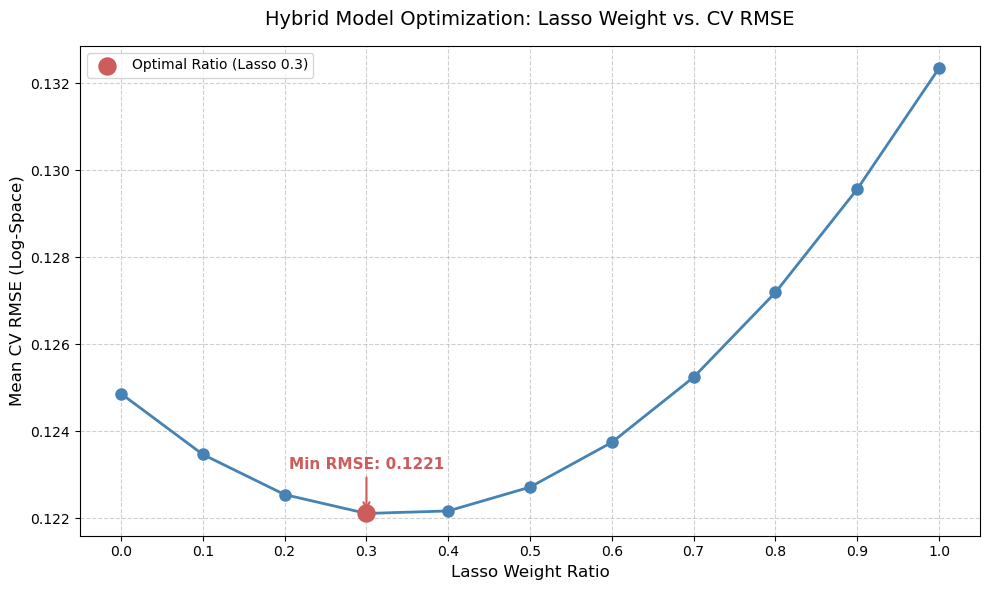

In [87]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingRegressor

# ==========================================
# 1. Construct Lasso Pipeline with Yeo-Johnson Transformation
# ==========================================
# The Yeo-Johnson transformer is utilized to stabilize variance and 
# minimize non-normality in the feature space, enhancing Lasso performance.
lasso_pipeline = Pipeline([
    ('yeo_johnson', PowerTransformer(method='yeo-johnson')),
    ('lasso', Lasso(alpha=lasso_cv.alpha_))
])

# Utilize the previously optimized Gradient Boosting model as the base learner
gb_model = best_gb_random_model 

# ==========================================
# 2. Empirical Weight Optimization (Rigorous K-Fold Standard)
# ==========================================
best_weight = 0
best_rmse = float('inf')
best_std = 0  # To track the stability (variance) of the optimal ratio

# Define the search space for the Lasso/GBR weighting ratio
weights_to_try = np.linspace(0, 1, 11) 

# Initialize lists to store metrics for visualization
history_weights = []
history_rmses = []
history_stds = []

print("Initiating rigorous K-Fold CV to identify the optimal Hybrid weights...\n")

for w in weights_to_try:
    # Construct the weighted ensemble for the current iteration
    # The weights correspond to [Lasso, GBR] respectively
    hybrid_model = VotingRegressor(
        estimators=[('lasso_pipe', lasso_pipeline), ('gbr', gb_model)],
        weights=[w, 1 - w]
    )

    # Execute 5-Fold Cross-Validation
    scores = cross_val_score(hybrid_model, X_dev, y_dev, cv=kf, scoring='neg_mean_squared_error')
    
    # APPLY RIGOROUS METRIC LOGIC: 
    # Calculate RMSE for each individual fold first, then derive the mean and standard deviation.
    fold_rmses = np.sqrt(np.abs(scores))
    mean_rmse = fold_rmses.mean()
    std_rmse = fold_rmses.std()
    
    # Log the iteration results
    history_weights.append(w)
    history_rmses.append(mean_rmse)
    history_stds.append(std_rmse)
    
    print(f"Testing Weight -> Lasso: {w:.1f} | GBR: {1-w:.1f} ==> CV RMSE: {mean_rmse:.5f} (± {std_rmse:.5f})")

    # Update global champion metrics if a superior RMSE is achieved
    if mean_rmse < best_rmse:
        best_rmse = mean_rmse
        best_weight = w
        best_std = std_rmse

# ==========================================
# 3. Final Model Summary
# ==========================================
print("\n" + "=" * 60)
print(" Hybrid Optimization Complete")
print("-" * 60)
print(f" Optimal Lasso Weight: {best_weight:.1f}")
print(f" Optimal GBR Weight:   {1 - best_weight:.1f}")
print(f" Minimum CV RMSE:      {best_rmse:.5f} (± {best_std:.5f})")
print("=" * 60)

# ==========================================
# 4. Optimization Trajectory Visualization
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the RMSE trend across the weighting spectrum
plt.plot(history_weights, history_rmses, marker='o', linestyle='-', color='steelblue', linewidth=2, markersize=8)

# Annotate the optimal local minimum
plt.scatter([best_weight], [best_rmse], color='indianred', s=150, zorder=5, label=f'Optimal Ratio (Lasso {best_weight:.1f})')
plt.annotate(f'Min RMSE: {best_rmse:.4f}', 
             xy=(best_weight, best_rmse), 
             xytext=(best_weight, best_rmse + (max(history_rmses)-min(history_rmses))*0.1),
             ha='center', fontsize=11, color='indianred', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='indianred', lw=1.5))

# Refine plot aesthetics for technical reporting
plt.title('Hybrid Model Optimization: Lasso Weight vs. CV RMSE', fontsize=14, pad=15)
plt.xlabel('Lasso Weight Ratio', fontsize=12)
plt.ylabel('Mean CV RMSE (Log-Space)', fontsize=12)
plt.xticks(weights_to_try)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

In [88]:
# ==========================================
# 5. Training the Final Optimized Hybrid Model
# ==========================================
print("\nTraining the final Hybrid model using 100% of the development set...")

# Initialize the VotingRegressor with the previously identified optimal weight distribution
best_hybrid_model = VotingRegressor(
    estimators=[('lasso_pipe', lasso_pipeline), ('gbr', gb_model)],
    weights=[best_weight, 1 - best_weight]
)

# Train the champion model on all available development data (X_dev, y_dev)
best_hybrid_model.fit(X_dev, y_dev)


# ==========================================
# 6. Final Inference and Validation on Hold-out Test Set
# ==========================================
print("Performing final predictions on the Test Dataset...")

# Generate predictions for the final evaluation
hybrid_final_preds = best_hybrid_model.predict(X_final_test)

# Calculate the RMSE on the test set using the standardized Log-Space metric
hybrid_final_test_rmse = np.sqrt(mean_squared_error(y_final_test, hybrid_final_preds))

# ==========================================
# 7. Final Performance Report
# ==========================================
print("\n" + "="*45)
print(" Final Evaluation: Hybrid Model (Lasso + GBR)")
print("="*45)
print(f" Final Hybrid Test RMSE (Log-Space): {hybrid_final_test_rmse:.4f}")
print(f" Final Hybrid Mean Percentage Error: {(np.exp(hybrid_final_test_rmse) - 1)*100:.2f}%")
print("=" * 45)


Training the final Hybrid model using 100% of the development set...
Performing final predictions on the Test Dataset...

 Final Evaluation: Hybrid Model (Lasso + GBR)
 Final Hybrid Test RMSE (Log-Space): 0.1292
 Final Hybrid Mean Percentage Error: 13.79%


In [89]:

print("--- ( Test Error) ---")
print(f"Baseline Test RMSE (Log-Space): {baseline_test_rmse:.4f}")
print(f"Lasso Test RMSE (Log-Space): {lasso_test_rmse:.4f}")
print(f"Ridge Test RMSE (Log-Space): {ridge_test_rmse:.4f}")
print(f"GB Test RMSE (Log-Space): {gb_random_final_test_rmse:.4f}")
print(f"Hybrid (Lasso + GBR) Test RMSE (Log-Space): {hybrid_final_test_rmse:.4f}")
print("="*40)
print(f"Basline Mean Percentage Error: {(np.exp(baseline_test_rmse) - 1)*100:.2f}%")
print(f"Lasso Mean Percentage Error: {(np.exp(lasso_test_rmse) - 1)*100:.2f}%")
print(f"Ridge Mean Percentage Error: {(np.exp(ridge_test_rmse) - 1)*100:.2f}%")
print(f"GB Mean Percentage Error: {(np.exp(gb_random_final_test_rmse) - 1)*100:.2f}%")
print(f"Hybrid (Lasso + GBR) Mean Percentage Error: {(np.exp(hybrid_final_test_rmse) - 1)*100:.2f}%")
print("=" * 45)

--- ( Test Error) ---
Baseline Test RMSE (Log-Space): 0.2445
Lasso Test RMSE (Log-Space): 0.1352
Ridge Test RMSE (Log-Space): 0.1421
GB Test RMSE (Log-Space): 0.1318
Hybrid (Lasso + GBR) Test RMSE (Log-Space): 0.1292
Basline Mean Percentage Error: 27.69%
Lasso Mean Percentage Error: 14.48%
Ridge Mean Percentage Error: 15.27%
GB Mean Percentage Error: 14.08%
Hybrid (Lasso + GBR) Mean Percentage Error: 13.79%


Advanced Ensemble Methodology: Stacked Generalization (Stacking : Lasso + Ridge + GBR)

In [91]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline

print("\n" + "="*45)
print(" Initializing and Training Stacking Ensemble...")
print("="*45)

# Ensure consistent preprocessing for linear base learners
ridge_pipeline = Pipeline([
    ('yeo_johnson', PowerTransformer(method='yeo-johnson')),
    ('ridge', Lasso(alpha=ridge_cv.alpha_))
])

# ==========================================
# 1. Level 0: Base Learner Assembly
# ==========================================
# We assemble a diverse 'team' of base learners to capture different patterns.
# Linear models (Lasso/Ridge) are wrapped in Pipelines to ensure the 
# Yeo-Johnson transformation is applied correctly without data leakage.
estimators = [
    ('lasso_pipe', lasso_pipeline), # Linearized Lasso via Yeo-Johnson
    ('ridge_pipe', ridge_pipeline), # Regularized Ridge Pipeline
    ('gbr', best_gb_random_model)   # Non-linear Gradient Boosting champion
]

# ==========================================
# 2. Level 1: Meta-Model Configuration
# ==========================================
# The Meta-Learner (final_estimator) acts as the 'aggregator.' 
# We utilize RidgeCV to consolidate the base predictions while 
# maintaining L2 regularization to prevent meta-level overfitting.
stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=RidgeCV(),
    cv=kf,      # Utilizing our rigorous 5-Fold Cross-Validation strategy
    n_jobs=-1   # Parallel processing enabled for maximum performance
)

# Perform Cross-Validation to assess the stability of the Stacking architecture
stacking_cv_scores = cross_val_score(
    stacking_model, 
    X_dev, 
    y_dev, 
    cv=kf, 
    scoring='neg_mean_squared_error',
    n_jobs=-1 
)

# RIGOROUS METRIC LOGIC: 
# Extract RMSE for each fold independently before calculating the mean and standard deviation.
stacking_fold_rmses = np.sqrt(np.abs(stacking_cv_scores))
stacking_mean_rmse = stacking_fold_rmses.mean()
stacking_std_rmse = stacking_fold_rmses.std()

# Output the stability report for the ensemble
print(f"Per-Fold RMSE Results: {np.round(stacking_fold_rmses, 4)}")
print(f"Stacking Mean CV RMSE: {stacking_mean_rmse:.4f} (± {stacking_std_rmse:.4f})")
print("="*50)

# ==========================================
# 3. Final Model Synthesis and Inference
# ==========================================
print("Training the Stacking model on the full development set...")
# Note: StackingRegressor uses Out-of-Fold predictions during fit() to avoid leakage.
stacking_model.fit(X_dev, y_dev)

print("Performing final predictions on the Hold-out Test Dataset...")
stacking_final_preds = stacking_model.predict(X_final_test)

# ==========================================
# 4. Final Performance Evaluation
# ==========================================
# Evaluate using the standardized Log-Space RMSE metric
stacking_final_test_rmse = np.sqrt(mean_squared_error(y_final_test, stacking_final_preds))

print("\n--- ( Final Stacking Performance ) ---")
print(f" Stacking Test RMSE (Log-Space): {stacking_final_test_rmse:.4f}")
print(f" Stacking Mean Percentage Error: {(np.exp(stacking_final_test_rmse) - 1)*100:.2f}%")
print("=" * 45)


 Initializing and Training Stacking Ensemble...
[CV] END learning_rate=0.01, max_depth=3, n_estimators=500, subsample=0.9; total time=   2.2s
[CV] END learning_rate=0.01, max_depth=3, n_estimators=1000, subsample=0.9; total time=   4.6s
[CV] END learning_rate=0.01, max_depth=4, n_estimators=500, subsample=0.9; total time=   3.0s
[CV] END learning_rate=0.01, max_depth=4, n_estimators=1000, subsample=0.9; total time=   6.0s
[CV] END learning_rate=0.01, max_depth=5, n_estimators=500, subsample=0.9; total time=   3.6s
[CV] END learning_rate=0.01, max_depth=5, n_estimators=1000, subsample=0.9; total time=   7.1s
[CV] END learning_rate=0.05, max_depth=3, n_estimators=1000, subsample=0.8; total time=   4.1s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=500, subsample=0.8; total time=   2.6s
[CV] END learning_rate=0.05, max_depth=4, n_estimators=1000, subsample=0.8; total time=   5.2s
[CV] END learning_rate=0.05, max_depth=5, n_estimators=500, subsample=0.8; total time=   3.7s
[CV] E

In [92]:
# ==========================================
# 1. Extract the Trained Meta-Model
# ==========================================
# Retrieve the fitted RidgeCV meta-estimator from the Stacking ensemble
meta_model = stacking_model.final_estimator_

# ==========================================
# 2. Extract Base Model Coefficients
# ==========================================
# Retrieve the learned weights assigned to the predictions of each base learner
weights = meta_model.coef_

print("\n" + "="*50)
print(" Stacking Meta-Model: Learned Weight Distribution")
print("="*50)
print(f" Lasso Weight (Coefficient): {weights[0]:.4f}")
print(f" Ridge Weight (Coefficient): {weights[1]:.4f}")
print(f" GBR   Weight (Coefficient): {weights[2]:.4f}")
print(f" Baseline Offset (Intercept): {meta_model.intercept_:.4f}")
print("="*50)


 Stacking Meta-Model: Learned Weight Distribution
 Lasso Weight (Coefficient): 0.3699
 Ridge Weight (Coefficient): 0.0158
 GBR   Weight (Coefficient): 0.6426
 Baseline Offset (Intercept): -0.3388


Advanced Ensemble Methodology: Stacked Generalization (Stacking: Lasso + GBR)

In [94]:
# ==========================================
# 1. Ensemble Pruning: Lean Stacking Architecture
# ==========================================
# Retaining only the strongest, mutually exclusive model paradigms to reduce noise
lean_estimators = [
    ('lasso_pipe', lasso_pipeline), # Linear architecture representative
    ('gbr', best_gb_random_model)   # Tree-based architecture representative
]

# Initialize the refined Stacking model
lean_stacking_model = StackingRegressor(
    estimators=lean_estimators,
    final_estimator=RidgeCV(),
    cv=kf,
    n_jobs=-1
)

# Execute cross-validation on the refined ensemble
lean_stacking_cv_scores = cross_val_score(
    lean_stacking_model, 
    X_dev, 
    y_dev, 
    cv=kf, 
    scoring='neg_mean_squared_error',
    n_jobs=-1 # Utilize all available CPU cores for parallel processing
)

# ==========================================
# 2. Rigorous Evaluation Metric Logic
# ==========================================
# Extract RMSE per fold before calculating the aggregate mean and standard deviation
stacking_fold_rmses = np.sqrt(np.abs(lean_stacking_cv_scores))
stacking_mean_rmse = stacking_fold_rmses.mean()
stacking_std_rmse = stacking_fold_rmses.std()

# Output the stability and performance report
print(f"Per-Fold RMSE Results: {np.round(stacking_fold_rmses, 4)}")
print(f" Lean Stacking Mean CV RMSE: {stacking_mean_rmse:.4f} (± {stacking_std_rmse:.4f})")
print("="*50)

# ==========================================
# 3. Final Model Synthesis and Inference
# ==========================================
print("Training Lean Stacking Model (Lasso + GBR) on the full development set...")
lean_stacking_model.fit(X_dev, y_dev)

print("Performing final predictions on the Hold-out Test Dataset...")
lean_stacking_preds = lean_stacking_model.predict(X_final_test)

# Calculate final test metrics
lean_stacking_rmse = np.sqrt(mean_squared_error(y_final_test, lean_stacking_preds))

print("\n--- ( Final Lean Stacking Performance ) ---")
print(f" Lean Stacking Test RMSE (Log-Space): {lean_stacking_rmse:.4f}")
print(f" Lean Stacking Mean Percentage Error: {(np.exp(lean_stacking_rmse) - 1)*100:.2f}%")
print("=" * 45)

Per-Fold RMSE Results: [0.1272 0.128  0.1522 0.1049 0.1035]
 Lean Stacking Mean CV RMSE: 0.1232 (± 0.0179)
Training Lean Stacking Model (Lasso + GBR) on the full development set...
Performing final predictions on the Hold-out Test Dataset...

--- ( Final Lean Stacking Performance ) ---
 Lean Stacking Test RMSE (Log-Space): 0.1285
 Lean Stacking Mean Percentage Error: 13.71%


In [95]:
# ==========================================
# 1. Extract the Trained Meta-Model
# ==========================================
# Retrieve the fitted RidgeCV meta-estimator from the Lean Stacking ensemble
lean_meta_model = lean_stacking_model.final_estimator_

# ==========================================
# 2. Extract Base Model Coefficients
# ==========================================
# Retrieve the learned weights assigned to the linear and tree-based predictions
weights = lean_meta_model.coef_

print("\n" + "="*50)
print(" Lean Stacking Meta-Model: Learned Weight Distribution")
print("="*50)
print(f" Lasso Weight (Coefficient): {weights[0]:.4f}")
print(f" GBR   Weight (Coefficient): {weights[1]:.4f}")
print(f" Baseline Offset (Intercept): {lean_meta_model.intercept_:.4f}")
print("="*50)


 Lean Stacking Meta-Model: Learned Weight Distribution
 Lasso Weight (Coefficient): 0.3699
 GBR   Weight (Coefficient): 0.6426
 Baseline Offset (Intercept): -0.1491


Advanced Ensemble Methodology: Stacked Generalization (Stacking: Ridge + GBR)

In [97]:
# ==========================================
# 1. Lean Stacking: Retaining the strongest complementary models
# ==========================================
ridge_lean_estimators = [
    ('ridge_pipe', ridge_pipeline), # Linear architecture representative
    ('gbr', best_gb_random_model)   # Tree-based architecture representative
]

# Initialize the refined Stacking model
# (Note: duplicate initialization from the original snippet has been consolidated)
ridge_lean_stacking_model = StackingRegressor(
    estimators=ridge_lean_estimators,
    final_estimator=RidgeCV(),
    cv=kf,
    n_jobs=-1
)

# Execute cross-validation on the refined ensemble
ridge_lean_stacking_cv_scores = cross_val_score(
    ridge_lean_stacking_model, 
    X_dev, 
    y_dev, 
    cv=kf, 
    scoring='neg_mean_squared_error',
    n_jobs=-1 # Utilize all available CPU cores
)

# ==========================================
# 2. Strict Evaluation Metric Logic
# ==========================================
# Extract RMSE per fold before calculating the aggregate mean and standard deviation
stacking_fold_rmses = np.sqrt(np.abs(ridge_lean_stacking_cv_scores))
stacking_mean_rmse = stacking_fold_rmses.mean()
stacking_std_rmse = stacking_fold_rmses.std()

# ==========================================
# 3. Output Final Stability Report
# ==========================================
print(f"Per-Fold RMSE Results: {np.round(stacking_fold_rmses, 4)}")
print(f" Stacking Mean CV RMSE: {stacking_mean_rmse:.4f} (± {stacking_std_rmse:.4f})")
print("="*50)

# ==========================================
# 4. Final Training and Inference
# ==========================================
print("Training the Lean Stacking model (Ridge + GBR)...")
ridge_lean_stacking_model.fit(X_dev, y_dev)
ridge_lean_stacking_preds = ridge_lean_stacking_model.predict(X_final_test)

# Calculate updated metrics on the hold-out test set
ridge_lean_stacking_rmse = np.sqrt(mean_squared_error(y_final_test, ridge_lean_stacking_preds))

print(f" Lean Stacking Test RMSE: {ridge_lean_stacking_rmse:.4f}")
print(f" Lean Stacking MPE:       {(np.exp(ridge_lean_stacking_rmse) - 1)*100:.2f}%")

Per-Fold RMSE Results: [0.1316 0.1325 0.1459 0.1085 0.1065]
 Stacking Mean CV RMSE: 0.1250 (± 0.0152)
Training the Lean Stacking model (Ridge + GBR)...
 Lean Stacking Test RMSE: 0.1316
 Lean Stacking MPE:       14.06%


In [98]:
# ==========================================
# 1. Extract the Trained Meta-Model
# ==========================================
# Retrieve the fitted final estimator (meta-learner) from the stacking ensemble
lean_meta_model = ridge_lean_stacking_model.final_estimator_

# ==========================================
# 2. Extract Base Model Coefficients
# ==========================================
# Retrieve the learned weights assigned to the level-0 predictors (Ridge and GBR)
weights = lean_meta_model.coef_

print("\n" + "="*50)
print(" Stacking Lean Meta-Model: Weight Distribution")
print("="*50)
print(f" Ridge Weight (Coefficient): {weights[0]:.4f}")
print(f" GBR   Weight (Coefficient): {weights[1]:.4f}")
print(f" Intercept (Bias Term):       {lean_meta_model.intercept_:.4f}")
print("="*50)


 Stacking Lean Meta-Model: Weight Distribution
 Ridge Weight (Coefficient): 0.1318
 GBR   Weight (Coefficient): 1.0091
 Intercept (Bias Term):       -1.6918


Hyperparameter Optimization: XGBoost via Randomized Search

In [100]:
import xgboost as xgb
from scipy.stats import randint, uniform

# ==========================================
# 1. Define XGBoost Continuous Parameter Space
# ==========================================
# We define distributions for randomized sampling rather than fixed grids
xgb_param_dist = {
    'n_estimators': randint(300, 1500),
    'learning_rate': uniform(0.01, 0.09),
    'max_depth': randint(3, 8),
    'subsample': uniform(0.6, 0.4),           # Samples 60% to 100% of the training data
    'colsample_bytree': uniform(0.6, 0.4),    # Feature sampling per tree (XGBoost specific)
    'min_child_weight': randint(1, 10),       # Minimum sum of instance weight in a leaf
    'reg_alpha': uniform(0, 1),               # L1 regularization (Lasso equivalent)
    'reg_lambda': uniform(0, 1)               # L2 regularization (Ridge equivalent)
}

# Initialize the XGBoost Regressor
xgb_model = xgb.XGBRegressor(random_state=42)

# ==========================================
# 2. Configure RandomizedSearchCV Object
# ==========================================
xgb_random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_param_dist,
    n_iter=100,              # Total iterations of random parameter sampling
    cv=kf,                   # Utilizing the standardized 5-fold cross-validation
    scoring='neg_mean_squared_error',
    n_jobs=-1,               # Parallel processing enabled
    verbose=2,
    random_state=42
)

# ==========================================
# 3. Execution of Parameter Search
# ==========================================
print("Initiating XGBoost 5-fold parameter exploration. Please wait...")
xgb_random_search.fit(X_dev, y_dev)

# ==========================================
# 4. Analysis of Cross-Validation Results
# ==========================================
print("\n" + "=" * 45)
print(" Optimized XGBoost Hyperparameters:")
for key, value in xgb_random_search.best_params_.items():
    if isinstance(value, float) or type(value).__name__ == 'float64':
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")
print("-" * 45)

# Adhering to the project-standard evaluation metric
xgb_best_cv_rmse = np.sqrt(np.abs(xgb_random_search.best_score_))
print(f" Mean CV RMSE Score: {xgb_best_cv_rmse:.4f}")
print("=" * 45)

# Retrieve the best estimator trained on the full development set
best_xgb_model = xgb_random_search.best_estimator_

Initiating XGBoost 5-fold parameter exploration. Please wait...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

 Optimized XGBoost Hyperparameters:
  colsample_bytree: 0.6206
  learning_rate: 0.0351
  max_depth: 3
  min_child_weight: 1
  n_estimators: 1453
  reg_alpha: 0.5309
  reg_lambda: 0.4478
  subsample: 0.8212
---------------------------------------------
 Mean CV RMSE Score: 0.1248


In [101]:
print("\n" + "="*50)
print(" XGBoost Evaluation: Final Test Dataset")
print("="*50)

# ==========================================
# 1. Inference on the Final Test Dataset
# ==========================================
# The best_xgb_model object contains the optimal hyperparameters identified via 
# RandomizedSearchCV and has been refitted on the entire development dataset (X_dev).
xgb_tuned_final_preds = best_xgb_model.predict(X_final_test)

# ==========================================
# 2. Performance Metric Calculation
# ==========================================
# Calculate the final RMSE in Log-Space to ensure consistency with prior models.
xgb_tuned_final_test_rmse = np.sqrt(mean_squared_error(y_final_test, xgb_tuned_final_preds))

# ==========================================
# 3. Output Performance Summary
# ==========================================
print(f" Tuned XGBoost Test RMSE (Log-Space): {xgb_tuned_final_test_rmse:.4f}")
print(f" Tuned XGBoost Mean Percentage Error: {(np.exp(xgb_tuned_final_test_rmse) - 1)*100:.2f}%")
print("=" * 50)


 XGBoost Evaluation: Final Test Dataset
 Tuned XGBoost Test RMSE (Log-Space): 0.1299
 Tuned XGBoost Mean Percentage Error: 13.87%


Ultimate Ensemble Methodology: Tri-Model Stacking (Lasso + GBR + XGBoost)

In [ ]:
print("\n" + "="*50)
print("Lasso + GBR + XGBoost Stacking")
print("="*50)

# ==========================================
# 1. Level 0: High-Performance Base Estimators
# ==========================================
# Ensure best_xgb_model is the optimal configuration identified 
# via RandomizedSearchCV in the previous optimization phase.
ultimate_estimators = [
    ('lasso_pipe', lasso_pipeline),       # Linear paradigm representative
    ('gbr', best_gb_random_model),        # Tree-based paradigm 1 (Standard Boosting)
    ('xgb', best_xgb_model)               # Tree-based paradigm 2 (Extreme Boosting)
]

# ==========================================
# 2. Level 1: Meta-Model Initialization
# ==========================================
# Utilizing RidgeCV as the aggregator to intelligently combine expert 
# predictions while preventing over-reliance on any single base learner.
ultimate_stacking_model = StackingRegressor(
    estimators=ultimate_estimators,
    final_estimator=RidgeCV(),
    cv=kf,
    n_jobs=-1
)

# ==========================================
# 3. Training and Final Inference
# ==========================================
print("Training Stacking model on the full development set (OOF computation in progress)...")
# Note: Out-of-Fold (OOF) predictions are generated to train the meta-model without data leakage.
ultimate_stacking_model.fit(X_dev, y_dev)
ultimate_stacking_preds = ultimate_stacking_model.predict(X_final_test)

# ==========================================
# 4. Final Performance Evaluation
# ==========================================
ultimate_stacking_rmse = np.sqrt(mean_squared_error(y_final_test, ultimate_stacking_preds))

print("\n--- ( Final Ultimate Stacking Error ) ---")
print(f" Ultimate Stacking Test RMSE (Log): {ultimate_stacking_rmse:.4f}")
print(f" Ultimate Stacking MPE:       {(np.exp(ultimate_stacking_rmse) - 1)*100:.2f}%")
print("="*50)

# ==========================================
# 5. Meta-Model Diagnostics: Feature Influence
# ==========================================
# Analyzing the coefficients of the Level 1 meta-learner to identify 
# which base expert provides the most reliable signal.
ultimate_meta_model = ultimate_stacking_model.final_estimator_
ultimate_weights = ultimate_meta_model.coef_

print("\nMeta-model Weight Distribution")
print("-" * 30)
print(f"Lasso Weight (Coefficient): {ultimate_weights[0]:.4f}")
print(f"GBR   Weight (Coefficient): {ultimate_weights[1]:.4f}")
print(f"XGB   Weight (Coefficient): {ultimate_weights[2]:.4f}")
print(f"Baseline Offset (Intercept): {ultimate_meta_model.intercept_:.4f}")
print("-" * 30)


Lasso + GBR + XGBoost Stacking
Training Stacking model on the full development set (OOF computation in progress)...


In [ ]:
print("--- ( Test Error) ---")
print(f"Baseline Test RMSE (Log-Space): {baseline_test_rmse:.4f}")
print(f"Lasso Test RMSE (Log-Space): {lasso_test_rmse:.4f}")
print(f"Ridge Test RMSE (Log-Space): {ridge_test_rmse:.4f}")
print(f"GB Test RMSE (Log-Space): {gb_random_final_test_rmse:.4f}")
print(f"Hybrid Test RMSE (Log-Space): {hybrid_final_test_rmse:.4f}")
print(f"Stacking(Lasso + Ridge + GBR) Test RMSE (Log-Space): {stacking_final_test_rmse:.4f}")
print(f"XGBoost Test RMSE (Log-Space): {xgb_tuned_final_test_rmse:.4f}")
print(f"Ultimate Stacking(Lasso + GBR + XGBoost) Test RMSE (Log): {ultimate_stacking_rmse:.4f}")
print("="*40)
print(f"Basline Mean Percentage Error: {(np.exp(baseline_test_rmse) - 1)*100:.2f}%")
print(f"Lasso Mean Percentage Error: {(np.exp(lasso_test_rmse) - 1)*100:.2f}%")
print(f"Ridge Mean Percentage Error: {(np.exp(ridge_test_rmse) - 1)*100:.2f}%")
print(f"GB Mean Percentage Error: {(np.exp(gb_random_final_test_rmse) - 1)*100:.2f}%")
print(f"Hybrid Mean Percentage Error: {(np.exp(hybrid_final_test_rmse) - 1)*100:.2f}%")
print(f"Stacking(Lasso + Ridge + GBR) Mean Percentage Error: {(np.exp(stacking_final_test_rmse) - 1)*100:.2f}%")
print(f"XGBoost Mean Percentage Error: {(np.exp(xgb_tuned_final_test_rmse) - 1)*100:.2f}%")
print(f"Ultimate Stacking(Lasso + GBR + XGBoost) MPE: {(np.exp(ultimate_stacking_rmse) - 1)*100:.2f}%")
print("=" * 45)

In [ ]:
# ==========================================
# Final Model Comparison Bar Chart
# ==========================================
import matplotlib.pyplot as plt

models = [
    'Lasso',
    'Ridge',
    'GB',
    'Hybrid',
    'Stack',
    'XGBoost',
    'Ultimate Stack'
]

scores = [
    lasso_test_rmse,
    ridge_test_rmse,
    gb_random_final_test_rmse,
    hybrid_final_test_rmse,
    stacking_final_test_rmse,
    xgb_tuned_final_test_rmse,
    ultimate_stacking_rmse
]

plt.figure(figsize=(12,6))

bars = plt.bar(
    models,
    scores,
    color=[
        '#B8A1D9',
        '#7EAED3',
        '#D4A373',
        '#A8C686',
        '#6C91BF',
        '#E59866',
        '#5DADE2'
    ]
)

# Add RMSE labels above bars
for bar, score in zip(bars, scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        score + 0.001,
        f'{score:.4f}',
        ha='center',
        fontsize=10
    )

plt.ylabel('RMSE (Log-Space)', fontsize=13)

plt.title(
    'Final Model Comparison',
    fontsize=16,
    pad=15
)

# Zoom to emphasize differences
plt.ylim(min(scores) - 0.01, max(scores) + 0.01)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# ==========================================
# Metrics
# ==========================================
ultimate_r2 = r2_score(y_final_test, ultimate_stacking_preds)
ultimate_rmse = np.sqrt(
    mean_squared_error(y_final_test, ultimate_stacking_preds)
)

# ==========================================
# Actual vs Predicted Plot
# ==========================================
plt.figure(figsize=(8, 8))

# Scatter points
plt.scatter(
    y_final_test,
    ultimate_stacking_preds,
    alpha=0.65,
    edgecolor='white'
)

# Perfect prediction line
min_val = min(np.min(y_final_test), np.min(ultimate_stacking_preds))
max_val = max(np.max(y_final_test), np.max(ultimate_stacking_preds))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction ($y = \hat{y}$)'
)

# ==========================================
# Labels and title
# ==========================================
plt.title(
    'Ultimate Stacking: Actual vs Predicted House Prices',
    fontsize=14,
    pad=15
)

plt.xlabel('Actual Log(SalePrice)', fontsize=12)
plt.ylabel('Predicted Log(SalePrice)', fontsize=12)

# ==========================================
# Metrics box
# ==========================================
plt.text(
    min_val,
    max_val,
    f'$R^2 = {ultimate_r2:.4f}$\nRMSE = {ultimate_rmse:.4f}',
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round,pad=0.5',
        facecolor='white',
        alpha=0.9
    )
)

# ==========================================
# Styling
# ==========================================
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.axis('equal')
plt.tight_layout()

# Save high quality figure
plt.savefig(
    'ultimate_stacking_actual_vs_predicted.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# ==========================================
# Meta-model weights
# ==========================================
model_names = ['Lasso', 'Gradient Boosting', 'XGBoost']
weights = ultimate_weights

# ==========================================
# Plot
# ==========================================
plt.figure(figsize=(7,5))

bars = plt.bar(
    model_names,
    weights,
    edgecolor='black',
    width=0.8
)

# ==========================================
# Add padding on top
# ==========================================
plt.ylim(0, max(weights) + 0.08)

# ==========================================
# Add values above bars
# ==========================================
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        f'{yval:.3f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Ultimate Stacking Meta-Model Weights', pad=15)
plt.ylabel('Model Contribution Weight')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    'stacking_weights.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# Residuals
residuals = y_final_test - ultimate_stacking_preds

plt.figure(figsize=(7,5))

plt.scatter(
    ultimate_stacking_preds,
    residuals,
    alpha=0.6,
    edgecolor='white'
)

# Zero-error line
plt.axhline(
    y=0,
    linestyle='--',
    linewidth=2
)

plt.xlabel('Predicted Log(SalePrice)')
plt.ylabel('Residuals')
plt.title('Ultimate Stacking Residual Plot')

plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

plt.savefig(
    'residual_plot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()